# Formula 1 Lap Time Prediction

## Saudi Arabian Grand Prix (2022-2025): Temporal Analysis and Predictive Modeling

This notebook documents the complete analysis pipeline for the Saudi Arabian GP, covering multi-season data consolidation, exploratory diagnostics, feature transformations, temporal validation, and comparison between Linear Regression and XGBoost.

---

## 1. Initial Setup: Imports and Environment

The first cell loads the scientific Python stack, visualization libraries, FastF1 utilities, and modeling dependencies used throughout the notebook.

In [1]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
import json
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import scipy.stats as stats
import statsmodels.api as sm
import xgboost as xgb
import optuna
import shap
from sklearn.ensemble import RandomForestRegressor

CACHE_DIR = './fastf1_cache'
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)
print(f"FastF1 cache enabled at: {os.path.abspath(CACHE_DIR)}")

BASE_PLOT_DIR = './f1_plots'
if not os.path.exists(BASE_PLOT_DIR):
    os.makedirs(BASE_PLOT_DIR)
print(f"Base directory for saving plots: {os.path.abspath(BASE_PLOT_DIR)}")

C:\Users\mpoli\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FastF1 cache enabled at: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\Notebooks\fastf1_cache
Base directory for saving plots: c:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Scripts\Notebooks\f1_plots


## Current Feature-Set Alignment

This notebook follows the same article-facing feature configuration used by the reproducible scripts. `Year` is treated as a numerical predictor, while `Driver`, `Team`, and `pirelliCompound` are categorical predictors. Saudi Arabia removes `TrackTemp_RBF_Median` and keeps `Pressure_RBF_Median` as the retained atmospheric-state proxy.

The PCA diagnostics use only predictors; `LapTime_seconds` is kept as the supervised target and is not included in PCA loadings.


---

## 2. Multi-Season Data Extraction (2022-2025)

### Objective

Build a longitudinal race dataset for the **Saudi Arabian Grand Prix** across multiple seasons, combining lap timing, tyre usage, weather information, driver/team identifiers, and race results.

The circuit is located in **Jeddah, Saudi Arabia**.

In [ ]:
start_year_analysis = 2022
end_year_analysis = 2026
target_gp_name = 'Saudi Arabian Grand Prix'
laps_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Saudi Arabia\Race\Laps'
weather_dir = r'C:\Users\mpoli\Desktop\UFOP\9 PERIODO\TCC\Data\Saudi Arabia\Race\Weather'
safe_gp_name = target_gp_name.lower().replace(' ', '_')

all_laps_data_by_year = {}
all_weather_data_by_year = {}
all_results_data_by_year = {}

print(f"--- Loading local data for {target_gp_name} ---")

for year in range(start_year_analysis, end_year_analysis):
    laps_file = os.path.join(laps_dir, f"{safe_gp_name}_laps_{year}.csv")
    weather_file = os.path.join(weather_dir, f"{safe_gp_name}_weather_{year}.csv")
    
    if os.path.exists(laps_file) and os.path.exists(weather_file):
        print(f"  [CSV] Loading and converting season {year}...")
        
        df_laps = pd.read_csv(laps_file)
        df_weather = pd.read_csv(weather_file)
        
        df_laps['Time'] = pd.to_timedelta(df_laps['Time'])
        df_weather['Time'] = pd.to_timedelta(df_weather['Time'])
        
        if 'LapTime' in df_laps.columns:
            df_laps['LapTime'] = pd.to_timedelta(df_laps['LapTime'])
        
        df_laps = df_laps.sort_values('Time')
        df_weather = df_weather.sort_values('Time')
        
        all_laps_data_by_year[year] = df_laps
        all_weather_data_by_year[year] = df_weather
    else:
        print(f"  [!] Files for {year} not found em '{laps_dir}'.")

print("\nStarting multi-season combination...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        laps_df = all_laps_data_by_year[year].copy()
        weather_df = all_weather_data_by_year[year].copy()
        
        laps_df['Year'] = year
        weather_df['Year'] = year
        
        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)

if not lista_de_dataframes_anuais_laps:
    print("No data found to process.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    
    cols_to_check = ['LapTime_seconds', 'TyreLife']
    if 'pirelliCompound' in clean_laps_df.columns:
        cols_to_check.append('pirelliCompound')
        
    clean_laps_df.dropna(subset=cols_to_check, inplace=True)
    clean_laps_df['Year'] = clean_laps_df['Year'].astype(int)

    print(f"Success! Total of {len(clean_laps_df)} clean laps prontas para o merge climático.")

---

## 3. Data Consolidation and Cleaning

### Quality Filtering with `IsAccurate`

The first quality gate is the FastF1 `IsAccurate` flag. This removes laps with non-representative race timing, such as laps affected by missing timing sectors or unreliable telemetry.

After loading yearly files, lap and weather records are aligned and consolidated into a single modeling table.

In [ ]:
print("Starting multi-season data loading...")
lista_de_dataframes_anuais_laps = []
lista_de_dataframes_anuais_weather = []

for year in range(start_year_analysis, end_year_analysis):
    if year in all_laps_data_by_year:
        print(f"Loading data for {target_gp_name} {year}...")
        laps_df = all_laps_data_by_year[year]
        weather_df = all_weather_data_by_year[year]
        weather_df['Year'] = year
        laps_df['Year'] = year

        lista_de_dataframes_anuais_laps.append(laps_df)
        lista_de_dataframes_anuais_weather.append(weather_df)
    else:
        print(f"No data for {target_gp_name} {year}.")

if not lista_de_dataframes_anuais_laps:
    print("No data found for the selected year range. Ending analysis.")
else:
    combined_laps_df = pd.concat(lista_de_dataframes_anuais_laps, ignore_index=True)
    print(f"\nData from {len(lista_de_dataframes_anuais_laps)} seasons successfully combined!")
    print(f"Total of {len(combined_laps_df)} laps loaded.")
    clean_laps_df = combined_laps_df[combined_laps_df['IsAccurate'] == True].copy()
    clean_laps_df.dropna(subset=['LapTime_seconds', 'TyreLife', 'pirelliCompound'], inplace=True)

    print(f"Analyzing {len(clean_laps_df)} clean laps from all seasons.")



    clean_laps_df['Year'] = clean_laps_df['Year'].astype(int)

    print(f"Total of {len(clean_laps_df)} clean laps for analysis.")

if not lista_de_dataframes_anuais_weather:
    print("No weather data found for the selected year range. Ending analysis.")
else:
    combined_weather_df = pd.concat(lista_de_dataframes_anuais_weather, ignore_index=True)
    print(f"Total of {len(combined_weather_df)} registros meteorológicos carregados.")
    print(f"\nData from {len(lista_de_dataframes_anuais_weather)} seasons successfully combined!")

---

## 4. Feature Engineering

### 4.1 Autoregressive History (`LapTime_prev`)

We create an immediate-history feature inside each driver stint:

$$\text{LapTime\_prev}_{i} = \text{LapTime\_seconds}_{i-1}$$

This feature captures short-term race pace continuity while respecting driver, year, and stint boundaries.

In [4]:
clean_laps_df = clean_laps_df.sort_values(['Year','Driver','Stint','LapNumber'])
clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)

combined_laps_df_filtered = clean_laps_df.sort_values('Time').reset_index(drop=True)

combined_weather_df = combined_weather_df.sort_values('Time').reset_index(drop=True)
combined_weather_df = combined_weather_df.sort_values('Year').reset_index(drop=True)


weather_df_filtered = combined_weather_df.copy()

combined_laps_df_filtered['Year'] = combined_laps_df_filtered['Year'].astype(int)
weather_df_filtered['Year'] = weather_df_filtered['Year'].astype(int)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)
weather_df_filtered = weather_df_filtered.sort_values(['Year', 'Time']).reset_index(drop=True)

combined_laps_df_filtered = combined_laps_df_filtered.sort_values('Time')
weather_df_filtered = weather_df_filtered.sort_values('Time')

seconds_margin = 60
laps_with_weather = pd.merge_asof(
    combined_laps_df_filtered,
    weather_df_filtered.drop_duplicates(subset=['Time', 'Year']),
    on='Time',
    by='Year',
    direction='backward',
    tolerance=pd.Timedelta(seconds=seconds_margin)
)

laps_with_weather['TempDelta'] = laps_with_weather['TrackTemp'] - laps_with_weather['AirTemp']

display(laps_with_weather['Team'].unique())
team_mapping = {
    'Alfa Romeo Racing': 'Kick Sauber',
    'Alfa Romeo': 'Kick Sauber',
    'Racing Point': 'Aston Martin',
    'Toro Rosso': 'Racing Bulls',
    'AlphaTauri': 'Racing Bulls',
    'RB': 'Racing Bulls',
    'Renault': 'Alpine'
}

laps_with_weather['Team'] = laps_with_weather['Team'].replace(team_mapping)
display(laps_with_weather['Team'].unique())

C:\Users\mpoli\AppData\Local\Temp\ipykernel_29996\1357446950.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_laps_df['LapTime_prev'] = clean_laps_df.groupby(['Year','Driver','Stint'])['LapTime_seconds'].shift(1)


array(['Red Bull Racing', 'Ferrari', 'McLaren', 'Aston Martin',
       'Mercedes', 'RB', 'Haas F1 Team', 'Williams', 'Alpine',
       'Kick Sauber', 'Alfa Romeo', 'AlphaTauri', 'Racing Bulls'],
      dtype=object)

array(['Red Bull Racing', 'Ferrari', 'McLaren', 'Aston Martin',
       'Mercedes', 'Racing Bulls', 'Haas F1 Team', 'Williams', 'Alpine',
       'Kick Sauber'], dtype=object)

---

## 5. Outlier Detection and Removal

### Motivation

Even after `IsAccurate`, atypical laps can remain due to traffic, recovery laps, isolated mistakes, or race interruptions.

### Approach

Outlier filtering is based on the distribution of lap-to-lap differences. The goal is to remove extreme transitions while preserving representative race pace behavior.

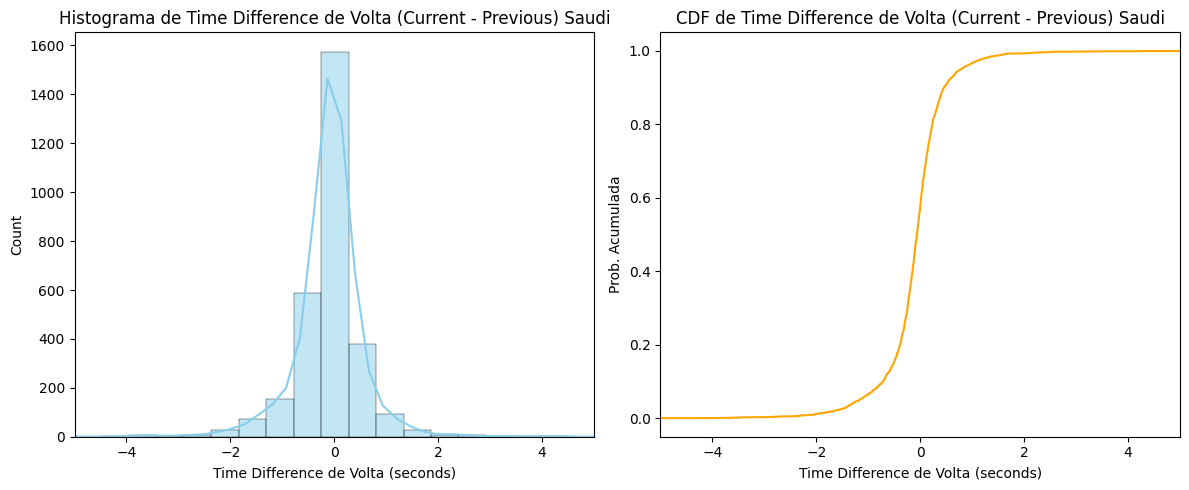

In [5]:
laps_with_weather['laps_diff'] = laps_with_weather['LapTime_seconds'] - laps_with_weather['LapTime_prev']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(laps_with_weather['laps_diff'].dropna(), kde=True, bins=100, color='skyblue')
plt.xlim(-5, 5) 
plt.title('Histograma de Time Difference de Volta (Current - Previous) Saudi')
plt.xlabel('Time Difference de Volta (seconds)')
plt.ylabel('Count')
plt.subplot(1, 2, 2)
sorted_diff = np.sort(laps_with_weather['laps_diff'].dropna())
cdf_vals = np.arange(1, len(sorted_diff)+1) / len(sorted_diff)
plt.plot(sorted_diff, cdf_vals, color='orange')
plt.xlim(-5, 5) 
plt.title('CDF de Time Difference de Volta (Current - Previous) Saudi')
plt.xlabel('Time Difference de Volta (seconds)')
plt.ylabel('Prob. Acumulada')
plt.tight_layout()
plt.show()

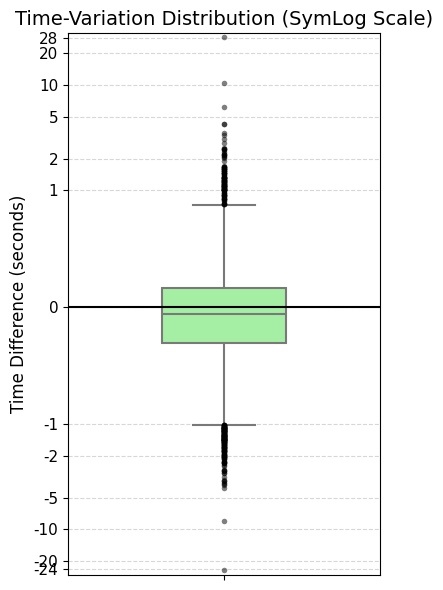

--- CANDIDATOS A CORTE PERFEITO ---
1. Conservador (Top 1%):  [-2.05s, 1.60s]
   (Removes only severe pit-stop and safety-car laps)

2. Statistical Pattern (IQR): [-1.01s, 0.87s]
   (The most commonly accepted academic rule for outliers)

3. Rigoroso (Top 5%):     [-1.17s, 0.79s]
   (Deixa apenas very consistent laps)


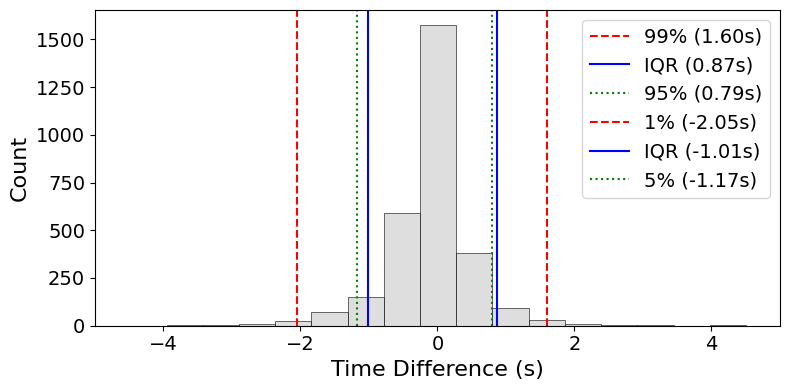

In [6]:
diff_data = laps_with_weather['laps_diff'].dropna()

plt.figure(figsize=(4, 6))

sns.boxplot(
    y=diff_data, 
    color='#98FB98', 
    width=0.4,       
    linewidth=1.5,   
    flierprops={"marker": "o", "markerfacecolor": "black", "markersize": 4, "alpha": 0.5, "markeredgecolor": "none"}
)

# Aplica a escala SymLog
plt.yscale('symlog', linthresh=1.0) 

custom_ticks = [-100, -50, -20, -10, -5, -2, -1, 0, 1, 2, 5, 10, 20, 50, 100]

min_val, max_val = diff_data.min(), diff_data.max()
visible_ticks = [t for t in custom_ticks if min_val <= t <= max_val]
if min_val < visible_ticks[0]: visible_ticks.insert(0, int(min_val))
if max_val > visible_ticks[-1]: visible_ticks.append(int(max_val))

plt.yticks(visible_ticks, labels=[str(t) for t in visible_ticks], fontsize=11)

plt.ylabel('Time Difference (seconds)', fontsize=12)
plt.title('Time-Variation Distribution (SymLog Scale)', fontsize=14)

plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')

plt.tight_layout()
plt.show()
p1 = np.percentile(diff_data, 1)
p99 = np.percentile(diff_data, 99)

Q1 = np.percentile(diff_data, 25)
Q3 = np.percentile(diff_data, 75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

p5 = np.percentile(diff_data, 5)
p95 = np.percentile(diff_data, 95)

print("--- CANDIDATOS A CORTE PERFEITO ---")
print(f"1. Conservador (Top 1%):  [{p1:.2f}s, {p99:.2f}s]")
print(f"   (Removes only severe pit-stop and safety-car laps)")
print(f"\n2. Statistical Pattern (IQR): [{lower_iqr:.2f}s, {upper_iqr:.2f}s]")
print(f"   (The most commonly accepted academic rule for outliers)")
print(f"\n3. Rigoroso (Top 5%):     [{p5:.2f}s, {p95:.2f}s]")
print(f"   (Deixa apenas very consistent laps)")

plt.figure(figsize=(8, 4))
sns.histplot(diff_data, bins=100, kde=False, color='lightgray')

plt.xlim(-5, 5) 

plt.axvline(p99, color='red', linestyle='--', label=f'99% ({p99:.2f}s)')
plt.axvline(upper_iqr, color='blue', linestyle='-', label=f'IQR ({upper_iqr:.2f}s)')
plt.axvline(p95, color='green', linestyle=':', label=f'95% ({p95:.2f}s)')
plt.axvline(p1, color='red', linestyle='--', label=f'1% ({p1:.2f}s)')
plt.axvline(lower_iqr, color='blue', linestyle='-', label=f'IQR ({lower_iqr:.2f}s)')
plt.axvline(p5, color='green', linestyle=':', label=f'5% ({p5:.2f}s)')  

plt.xlabel('Time Difference (s)', fontsize=16)
plt.ylabel('Count', fontsize=16)

plt.tick_params(axis='both', which='major', labelsize=14)

plt.legend(fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

In [7]:
mask_clean = (
    (laps_with_weather['laps_diff'] >= p5) &
    (laps_with_weather['laps_diff'] <= p95)
)

laps_cleaned = laps_with_weather[mask_clean].copy()

print(f"Total original: {len(laps_with_weather)}")
print(f"Total após filtro: {len(laps_cleaned)}")
print(f"Outliers removed (slow laps/Pit In): {len(laps_with_weather) - len(laps_cleaned)}")

Total original: 3106
Total após filtro: 2660
Outliers removed (slow laps/Pit In): 446


In [ ]:
try:
    stats_df_laps_diff = laps_with_weather.describe(include='all')

    features_of_interest = [ 'laps_diff'
    ]

    skewness = laps_with_weather.skew(numeric_only=True)

    kurtosis = laps_with_weather.kurt(numeric_only=True)

    means = laps_with_weather.mean(numeric_only=True)
    stds = laps_with_weather.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)

    cv_series = pd.Series(cv, index=means.index)

    stats_df_laps_diff = stats_df_laps_diff[features_of_interest]

    stats_df_laps_diff.loc['skewness'] = skewness
    stats_df_laps_diff.loc['kurtosis'] = kurtosis
    stats_df_laps_diff.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Estatísticas ---")
    display(stats_df_laps_diff)


except Exception as e:
    print(f"An error occurred while calculating the statistics: {e}")
    print("Check whether the DataFrame 'laps_with_weather' exists and is not empty.")

---

## 6. Exploratory Data Analysis (EDA): Univariate Distributions

### Objective

Inspect each variable independently before multivariate modeling. This helps validate data quality, identify skewness, detect long tails, and understand the empirical scale of the predictors used by the models.

In [ ]:
n_rows_cont = 5
n_cols_cont = 2
fig_cont, axes_cont = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cont = axes_cont.flatten()

continuous_cols = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds', 'Humidity',
    'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
]

num_df = laps_cleaned[continuous_cols].copy()

for i, col in enumerate(continuous_cols):
    ax = flat_axes_cont[i]

    data_to_plot = num_df[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'{col} (No Data)')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.histplot(data_to_plot, kde=True, ax=ax, bins=40, stat="density")
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Density')

plt.suptitle('Histograms of Continuous Numerical Features', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

### Compound-Specific `TyreLife` Behavior

Tyre-life histograms split by Pirelli compound reveal different degradation and usage profiles. This verifies that compound identity carries meaningful race-strategy information.

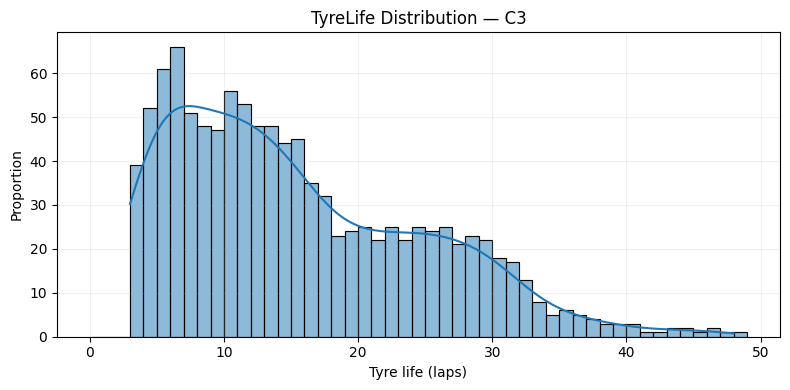

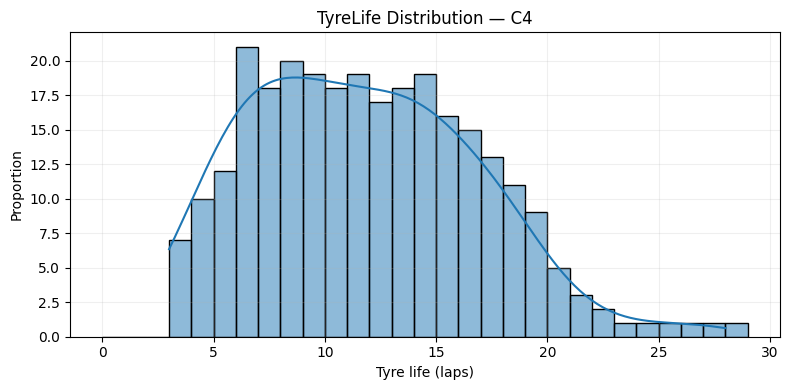

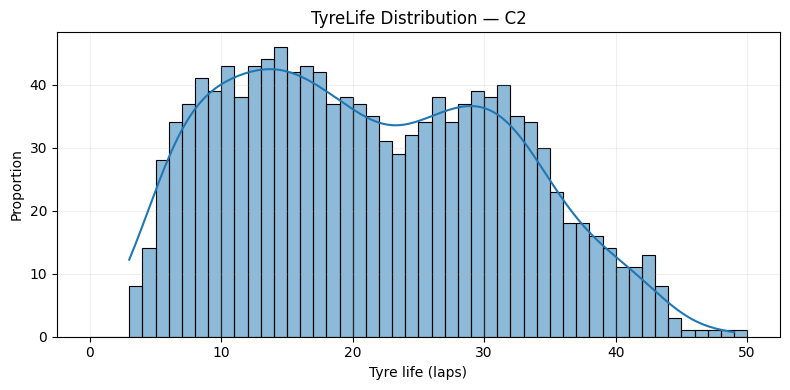

In [10]:
compounds_to_plot = ['C3','C4','C2']

for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['pirelliCompound'] == comp]
    elif 'Compound' in laps_cleaned.columns:
        subset = laps_cleaned[laps_cleaned['Compound'] == comp]
    else:
        subset = laps_cleaned[laps_cleaned.get('compound') == comp] if 'compound' in laps_cleaned.columns else laps_cleaned[[]]

    if subset.empty:
        print(f'No data available para o composto {comp}. Skipping.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'No valid TyreLife para {comp}. Skipping.')
        continue

    max_life = int(tyre_life.max()) if pd.api.types.is_numeric_dtype(tyre_life) else tyre_life.max()
    bins = range(0, max(2, max_life + 2)) if isinstance(max_life, int) else 10

    plt.figure(figsize=(8,4))
    sns.histplot(tyre_life, bins=bins, kde=True, color='C0', stat='count')
    plt.title(f'TyreLife Distribution — {comp}')
    plt.xlabel('Tyre life (laps)')
    plt.ylabel('Proportion')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

### Cumulative Distribution Function (CDF)

To complement histograms, we use the empirical CDF:

$$F(x) = P(X \leq x) = \frac{\#\{X_i \leq x\}}{n}$$

CDFs provide a bin-free view of the cumulative probability distribution and make it easier to compare variables with long-tailed behavior.

In [ ]:
fig_cdf, axes_cdf = plt.subplots(n_rows_cont, n_cols_cont, figsize=(15, 16))
flat_axes_cdf = axes_cdf.flatten()


for i, col in enumerate(continuous_cols):
    ax = flat_axes_cdf[i]

    data_to_plot = num_df[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'{col} (No Data)')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:

        sorted_vals = np.sort(data_to_plot)
        cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

        ax.plot(sorted_vals, cdf_vals)
        ax.set_title(f'CDF de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Prob. Acumulada')
        
plt.suptitle('CDF das Numerical Features Continuous', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

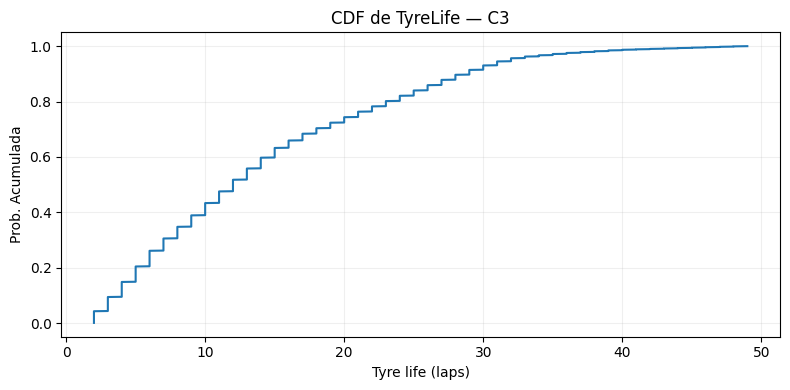

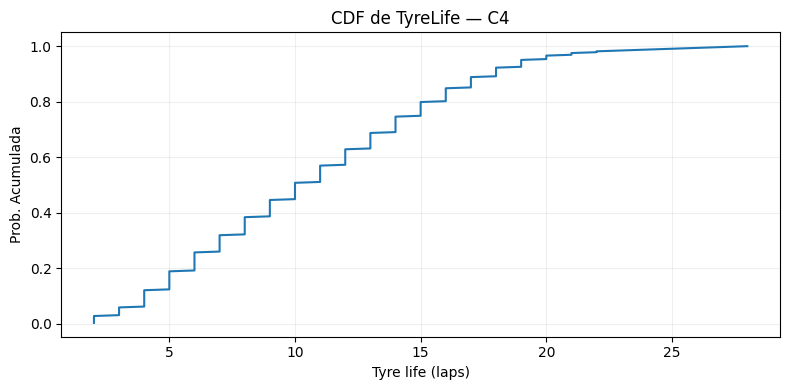

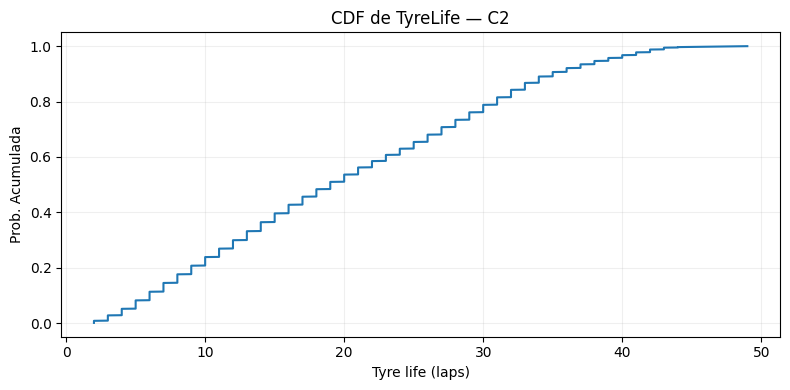

In [12]:
for comp in compounds_to_plot:
    if 'pirelliCompound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['pirelliCompound'] == comp]
    elif 'Compound' in laps_with_weather.columns:
        subset = laps_with_weather[laps_with_weather['Compound'] == comp]
    else:
        subset = laps_with_weather[laps_with_weather.get('compound') == comp] if 'compound' in laps_with_weather.columns else laps_with_weather[[]]

    if subset.empty:
        print(f'No data available para o composto {comp}. Skipping.')
        continue

    tyre_life = subset['TyreLife'].dropna()
    if tyre_life.empty:
        print(f'No valid TyreLife para {comp}. Skipping.')
        continue

    sorted_vals = np.sort(tyre_life)
    cdf_vals = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)

    plt.figure(figsize=(8,4))
    plt.plot(sorted_vals, cdf_vals, color='C0')
    plt.title(f'CDF de TyreLife — {comp}')
    plt.xlabel('Tyre life (laps)')
    plt.ylabel('Prob. Acumulada')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

---

## 7. Frequency Analysis: Categorical Variables

### Objective

Check class balance and representation across key categorical dimensions:

- `Driver`
- `Team`
- `pirelliCompound`
- `Year`

These distributions help explain potential model bias and the amount of information available for each group.

In [ ]:
cat_cols = ['Driver', 'Team', 'pirelliCompound']

print("Generating frequency plots (countplots) for categorical variables...")

sns.set_style("whitegrid")

n_rows_cat = 2
n_cols_cat = 2
fig_cat, axes_cat = plt.subplots(n_rows_cat, n_cols_cat, figsize=(22, 8))

flat_axes_cat = axes_cat.flatten()

for i, col in enumerate(cat_cols):
    ax = flat_axes_cat[i]

    data_to_plot = laps_cleaned[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'Frequência de {col} (No Data)')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        bar_order = data_to_plot.value_counts().index

        sns.countplot(x=data_to_plot, ax=ax, order=bar_order, palette="viridis")

        ax.set_title(f'Frequência de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count (Number of Laps)')

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Frequência de Variáveis Categóricas (Drivers, Pneus, Teams)', fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])

plt.show()

### Note on `TrackStatus`

`TrackStatus` encodes race-control states such as green flag, yellow flag, safety car, and red flag periods. Because this study already keeps only `IsAccurate=True` laps and focuses on regular race-pace modeling, `TrackStatus` is treated as an auxiliary diagnostic rather than a core predictor.

---

## 8. Dispersion and Outlier Diagnostics with Boxplots

Boxplots summarize the median, interquartile range (IQR), and extreme values of each numerical variable. They help verify whether the percentile-based filtering removed the most atypical observations while preserving the central race-pace distribution.

In [ ]:
n_rows = 5
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 16))
flat_axes = axes.flatten()

sns.set_style("whitegrid")

for i, col in enumerate(continuous_cols):
    ax = flat_axes[i]

    data_to_plot = laps_cleaned[col].dropna()

    if data_to_plot.empty:
        ax.set_title(f'Boxplot de {col} (No Data)')
        ax.text(0.5, 0.5, 'No Data', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
    else:
        sns.boxplot(y=data_to_plot, ax=ax, palette="viridis")
        ax.set_title(f'Boxplot de {col}')
        ax.set_xlabel('')
        ax.set_ylabel('Valor')

plt.suptitle('Boxplots de Numerical Features Continuous', fontsize=18, y=1.03)
plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

---

## 9. Descriptive Statistics and Distribution Moments

### Metrics

For the core numerical features, we report descriptive statistics and distribution moments, including skewness and kurtosis. These diagnostics support later transformation choices and help identify variables with asymmetric or heavy-tailed behavior.

In [ ]:
try:
    stats_df = laps_cleaned.describe(include='all')

    features_of_interest = [
    'LapTime_prev', 'TyreLife', 'LapNumber', 'LapTime_seconds',
    'Humidity', 'Pressure', 'TrackTemp', 'WindDirection', 'WindSpeed', 'TempDelta'
    ]

    skewness = laps_cleaned.skew(numeric_only=True)

    kurtosis = laps_cleaned.kurt(numeric_only=True)

    means = laps_cleaned.mean(numeric_only=True)
    stds = laps_cleaned.std(numeric_only=True)

    cv = np.where(means == 0, np.nan, stds / means)

    cv_series = pd.Series(cv, index=means.index)

    stats_df = stats_df[features_of_interest]

    stats_df.loc['skewness'] = skewness
    stats_df.loc['kurtosis'] = kurtosis
    stats_df.loc['CV (Coef. Var)'] = cv_series


    print("\n--- Estatísticas ---")
    display(stats_df)


except Exception as e:
    print(f"An error occurred while calculating the statistics: {e}")
    print("Check whether the DataFrame 'laps_with_weather' exists and is not empty.")

---

## 10. Skewness Diagnosis and Feature Transformation

### Why transform features?

Strong skewness can affect numerical stability and reduce model generalization. This section diagnoses asymmetric variables and applies transformations only when they are useful for the modeling pipeline.

In [16]:
skewed_features = {
    'right_skewed': [],
    'left_skewed': []
}

for feature in stats_df.columns:
    skewness_value = stats_df.at['skewness', feature]
    if pd.notna(skewness_value):
        if skewness_value > 1:
            skewed_features['right_skewed'].append(feature)
        elif skewness_value < -1:
            skewed_features['left_skewed'].append(feature)

print("\n--- Features com Skewness Significativo ---")
print("Right Skewed (skewness > 1):", skewed_features['right_skewed'])
print("Left Skewed (skewness < -1):", skewed_features['left_skewed'])


--- Features com Skewness Significativo ---
Right Skewed (skewness > 1): ['WindSpeed']
Left Skewed (skewness < -1): []


---

## 11. Strategic Analysis: Tyre Transition Matrix

### Objective

Estimate how often teams switch from one tyre compound to another between consecutive stints. This provides a compact view of race-strategy patterns and compound sequencing at the selected Grand Prix.

In [ ]:
print("Analyzing compound transitions between stints...")

try:

    stint_df = laps_cleaned[
        ['Year', 'Driver', 'Stint', 'pirelliCompound']
    ].drop_duplicates()

    stint_df = stint_df.sort_values(by=['Year', 'Driver', 'Stint'])

    stint_df['To_Compound'] = stint_df.groupby(['Year', 'Driver'])['pirelliCompound'].shift(-1)

    stint_df = stint_df.rename(columns={'pirelliCompound': 'From_Compound'})

    transitions_df = stint_df.dropna(subset=['To_Compound'])

    if transitions_df.empty:
        print("Could not find transition data (multiple stints) no DataFrame.")
    else:
        transition_matrix = pd.crosstab(
            transitions_df['From_Compound'],
            transitions_df['To_Compound']
        )

        print("\n--- Stint Transition Count Matrix ---")
        display(transition_matrix)

        print("\nGenerating transition-matrix heatmap...")
        plt.figure(figsize=(10, 7))

        ax = sns.heatmap(
            transition_matrix,
            annot=True,
            fmt="d",
            cmap="YlGnBu",
            linewidths=.5,
            cbar_kws={'label': 'Nº de Transitions (Stints)'}
        )

        ax.set_title('Tyre Compound Transition Matrix (Stint N $\to$ Stint N+1)')
        ax.set_xlabel('To Compound (Stint N+1)')
        ax.set_ylabel('From Compound (Stint N)')
        plt.tight_layout()
        plt.show()

except NameErrorr:
    print("Error: O DataFrame 'laps_with_weather_filtered' was not found.")
    print("Please run a célula anterior que define este DataFrame.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

---

## 12. Non-Linear Weather Transformations with RBF

### Motivation

Weather-performance relationships in Formula 1 are rarely purely linear. Around an operating region, changes in track temperature, humidity, pressure, wind speed, wind direction, and thermal delta may affect lap time in non-linear ways.

This notebook applies RBF-style transformations centered on historical medians for multimodal weather variables.

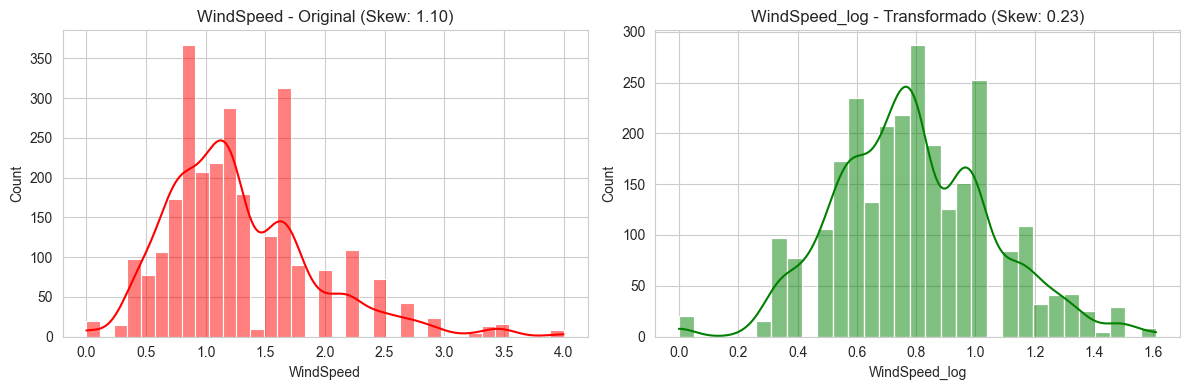

In [18]:
right_skewed_cols = skewed_features['right_skewed']

for col in right_skewed_cols:
    if col in laps_cleaned.columns:
        laps_cleaned[f'{col}_log'] = np.log1p(laps_cleaned[col])

for col in right_skewed_cols:
    if col in laps_cleaned.columns:
        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        sns.histplot(laps_cleaned[col], kde=True, ax=ax[0], color='red')
        ax[0].set_title(f'{col} - Original (Skew: {laps_cleaned[col].skew():.2f})')

        sns.histplot(laps_cleaned[f'{col}_log'], kde=True, ax=ax[1], color='green')
        ax[1].set_title(f'{col}_log - Transformado (Skew: {laps_cleaned[f"{col}_log"].skew():.2f})')

        plt.tight_layout()
        plt.show()

---

## 13. Multivariate Analysis: Pearson Correlation Matrix

### Objective

Quantify linear relationships among predictors and with `LapTime_seconds`, while inspecting potential multicollinearity.

The matrix uses Pearson correlation after combining numerical variables with one-hot encoded categorical variables.

Applying RBF transformation (Gamma=0.1) using the MEDIAN as reference...
Coluna 'TrackTemp': Mediana = 30.90
Coluna 'Humidity': Mediana = 59.00
Coluna 'Pressure': Mediana = 1011.20
Coluna 'WindSpeed': Mediana = 1.20
Coluna 'WindDirection': Mediana = 262.00
Coluna 'TempDelta': Mediana = 5.00


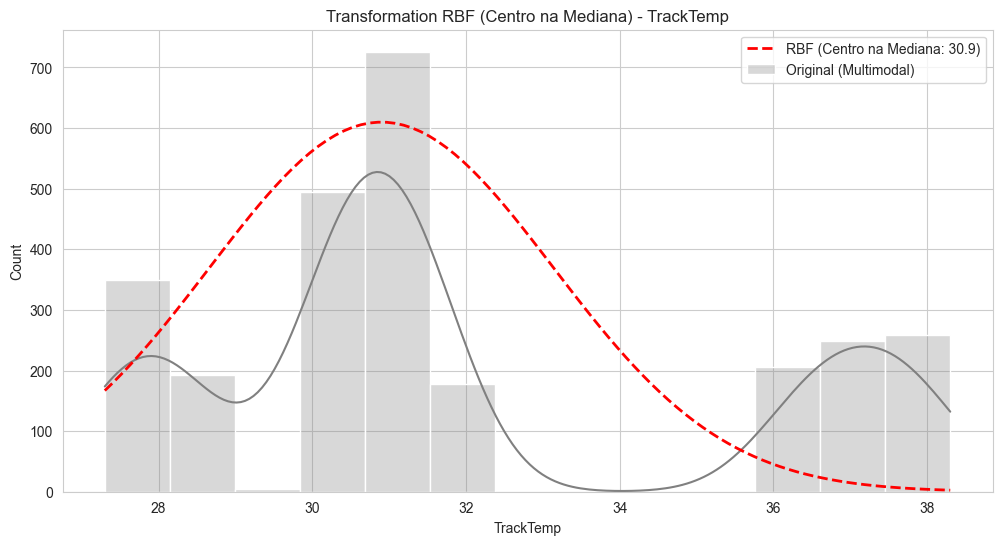


New Features Created: ['TrackTemp_RBF_Median', 'Humidity_RBF_Median', 'Pressure_RBF_Median', 'WindSpeed_RBF_Median', 'WindDirection_RBF_Median', 'TempDelta_RBF_Median']


In [19]:
weather_cols = ['TrackTemp', 'Humidity', 'Pressure', 'WindSpeed', 'WindDirection', 'TempDelta']
gamma_value = 0.1

print(f"Applying RBF transformation (Gamma={gamma_value}) using the MEDIAN as reference...")

for col in weather_cols:
    if col in laps_cleaned.columns:
        median_val = laps_cleaned[col].median()

        print(f"Coluna '{col}': Mediana = {median_val:.2f}")

        col_name = f"{col}_RBF_Median"

        squared_dist = (laps_cleaned[col] - median_val) ** 2
        laps_cleaned[col_name] = np.exp(-gamma_value * squared_dist)

        laps_cleaned[col_name] = laps_cleaned[col_name].fillna(0)

col_exemplo = 'TrackTemp'
if col_exemplo in weather_cols:
    col_transformed = f"{col_exemplo}_RBF_Median"
    median_exemplo = laps_cleaned[col_exemplo].median()

    plt.figure(figsize=(12, 6))
    ax1 = plt.gca()

    sns.histplot(laps_cleaned[col_exemplo], kde=True, ax=ax1, color='gray', alpha=0.3, label='Original (Multimodal)')

    x_range = np.linspace(laps_cleaned[col_exemplo].min(), laps_cleaned[col_exemplo].max(), 100)
    y_rbf = np.exp(-gamma_value * (x_range - median_exemplo)**2)

    y_max_hist = ax1.get_ylim()[1]
    plt.plot(x_range, y_rbf * y_max_hist * 0.8, color='red', linewidth=2, linestyle='--', label=f'RBF (Centro na Mediana: {median_exemplo:.1f})')

    plt.title(f'Transformation RBF (Centro na Mediana) - {col_exemplo}')
    plt.legend()
    plt.show()

new_features = [c for c in laps_cleaned.columns if '_RBF_Median' in c]
print(f"\nNew Features Created: {new_features}")

---

## 14. Dimensionality Reduction with PCA

### Why PCA?

With transformed numerical features and encoded categorical variables, PCA helps measure redundancy and summarize variance structure in a lower-dimensional space. The goal is diagnostic: to understand feature structure, not to replace the supervised models.

In [ ]:
num_cols = [
    'LapTime_seconds',
    'TyreLife',
    'LapNumber',
    'Humidity_RBF_Median',
    'Pressure_RBF_Median',
    'Year',
    'WindSpeed_RBF_Median',
    'TempDelta_RBF_Median',
    'LapTime_prev',
]

cat_cols = ['Driver', 'Team', 'pirelliCompound']

cat_dummies = pd.get_dummies(laps_cleaned[cat_cols].astype(str), prefix=cat_cols)
num_df = laps_cleaned[num_cols].copy()
corr_df_full = pd.concat([num_df, cat_dummies], axis=1)
corr_df_clean = corr_df_full.dropna()
corr_matrix = corr_df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(20, 12))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    annot=False, 
    fmt=".2f", 
    cbar_kws={"shrink": .8}, 
    linewidths=.5
)
plt.title('Correlation Matrix (Current Features and Target) - Saudi Arabia')
plt.tight_layout()
plt.show()

threshold = 0.80

strong_pos = []
strong_neg = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i):
        var1 = cols[i]
        var2 = cols[j]
        corr_value = corr_matrix.iloc[i, j]

        if pd.isna(corr_value):
            continue

        if corr_value > threshold:
            strong_pos.append((var1, var2, corr_value))
        elif corr_value < -threshold:
            strong_neg.append((var1, var2, corr_value))

strong_pos = sorted(strong_pos, key=lambda x: -x[2])
strong_neg = sorted(strong_neg, key=lambda x: x[2])

print(f"\nStrong positive correlations (> {threshold}):")
if strong_pos:
    for var1, var2, value in strong_pos:
        print(f"{var1} -- {var2}: {value:.3f}")
else:
    print("No strong positive correlation found.")

print(f"\nStrong negative correlations (< -{threshold}):")
if strong_neg:
    for var1, var2, value in strong_neg:
        print(f"{var1} -- {var2}: {value:.3f}")
else:
    print("No strong negative correlation found.")

---

## 15. Predictive Modeling I: Linear Regression Baseline

Before advanced models, we establish a transparent baseline with Linear Regression.

### Purpose

1. Provide a reference error level.
2. Evaluate how far a linear model can go with the engineered features.
3. Support interpretability through coefficients and statistical diagnostics.

In [ ]:
try:
    print("Starting data preparation for PCA")

    pca_num_cols = [col for col in num_cols if col != 'LapTime_seconds']
    pca_num_df = laps_cleaned[pca_num_cols].copy()
    ml_df_full = pd.concat([pca_num_df, cat_dummies], axis=1)

    imputer_num = SimpleImputer(strategy='mean')
    ml_df_imputed_num = imputer_num.fit_transform(ml_df_full[pca_num_cols])
    num_df_imputed = pd.DataFrame(ml_df_imputed_num, columns=pca_num_cols, index=ml_df_full.index)
    ml_df_imputed_analysis = pd.concat([num_df_imputed, cat_dummies], axis=1)

    scaler = StandardScaler()
    ml_df_scaled = scaler.fit_transform(ml_df_imputed_analysis)

    print(f"Dataset ready for ML. Shape: {ml_df_scaled.shape}")

    print("\n--- Running PCA ---")
    pca = PCA()
    pca.fit(ml_df_scaled)

    explained_variance_ratio = pca.explained_variance_ratio_
    print(explained_variance_ratio)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    plt.figure(figsize=(10, 6))
    num_components_to_plot = min(50, len(cumulative_variance))
    plt.bar(range(1, num_components_to_plot + 1), explained_variance_ratio[:num_components_to_plot], alpha=0.7, align='center', label='Individual Variance')
    plt.step(range(1, num_components_to_plot + 1), cumulative_variance[:num_components_to_plot], where='mid', label='Cumulative Variance', color='red')
    plt.axhline(y=0.95, color='g', linestyle='--', label='95% of Variance')
    plt.ylabel('Explained Variance Ratio'); plt.xlabel('Principal Components')
    plt.title('Explained Variance by Principal Components'); plt.legend(loc='best')
    plt.grid(True); plt.tight_layout()
    plt.show()

    n_components_95_idx = np.where(cumulative_variance >= 0.95)[0]
    if n_components_95_idx.size > 0:
        n_components_95 = n_components_95_idx[0] + 1
    else:
        n_components_95 = len(cumulative_variance)

    print(f"Number of Components for 95% of Variance: {n_components_95}")




except NameErrorr as e:
    print(f"ERROR: DataFrame 'laps_with_weather' was not found ({e}).")
    print("Please run a célula que carrega e processa os dados de UMA corrida primeiro (a que cria 'laps_with_weather').")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [ ]:
def plot_pca_loadings_subset_3d(pca, feature_list, full_feature_list, title):

    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]
    pc3 = loadings[:, 2]

    idx = [full_feature_list.get_loc(feat) for feat in feature_list]

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=pc1[idx],
        y=pc2[idx],
        z=pc3[idx],
        mode='markers+text',
        text=[full_feature_list[i] for i in idx],
        textposition="top center",
        marker=dict(
            size=6,
            line=dict(width=1, color='black')
        )
    ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="PC1",
            yaxis_title="PC2",
            zaxis_title="PC3",
        ),
        width=800,
        height=700
    )

    fig.show()

feature_names = ml_df_imputed_analysis.columns

lap_tyres_features = [
    'LapTime_prev',
    'TyreLife',
    'LapNumber',
    'pirelliCompound_C1',
    'pirelliCompound_C2',
    'pirelliCompound_C3',
    'pirelliCompound_C4',
    'pirelliCompound_C5',
]

plot_pca_loadings_subset_3d(
    pca,
    lap_tyres_features,
    feature_names,
    title="PCA Loadings - Lap Time and Tyres - Saudi Arabia"
)

weather_features = [
    'Humidity_RBF_Median',
    'Pressure_RBF_Median',
    'WindSpeed_RBF_Median',
    'TempDelta_RBF_Median',
    'Year',
]

plot_pca_loadings_subset_3d(
    pca,
    weather_features,
    feature_names,
    title="PCA Loadings - Weather and Year - Saudi Arabia"
)

team_features = [col for col in feature_names if col.startswith('Team_')]
plot_pca_loadings_subset_3d(
    pca,
    team_features,
    feature_names,
    title="PCA Loadings - Teams - Saudi Arabia"
)

driver_features = [col for col in feature_names if col.startswith('Driver_')]
plot_pca_loadings_subset_3d(
    pca,
    driver_features,
    feature_names,
    title="PCA Loadings - Drivers - Saudi Arabia"
)


In [ ]:
def plot_pca_loadings_subset_2d_static(pca, subset_features, full_feature_names, title):
    loadings = pca.components_.T
    pc1 = loadings[:, 0]
    pc2 = loadings[:, 1]

    if not isinstance(full_feature_names, pd.Index):
        full_feature_names = pd.Index(full_feature_names)

    subset_features = [f for f in subset_features if f in full_feature_names]
    if len(subset_features) == 0:
        print(f"[WARNING] No features found: {title}")
        return

    idx = [full_feature_names.get_loc(f) for f in subset_features]

    plt.figure(figsize=(8, 6))
    plt.scatter(pc1[idx], pc2[idx])

    for i, feat in zip(idx, subset_features):
        plt.text(pc1[i], pc2[i], feat, fontsize=9, ha='center', va='bottom')

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


feature_names = ml_df_imputed_analysis.columns

plot_pca_loadings_subset_2d_static(
    pca,
    [
        'LapTime_prev',
        'TyreLife',
        'LapNumber',
        'pirelliCompound_C2',
        'pirelliCompound_C3',
        'pirelliCompound_C4',
    ],
    feature_names,
    "PCA Loadings - Lap Time and Tyres - Saudi Arabia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [
        'Humidity_RBF_Median',
        'Pressure_RBF_Median',
        'WindSpeed_RBF_Median',
        'TempDelta_RBF_Median',
        'Year',
    ],
    feature_names,
    "PCA Loadings - Weather and Year - Saudi Arabia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Team_")],
    feature_names,
    "PCA Loadings - Teams - Saudi Arabia"
)

plot_pca_loadings_subset_2d_static(
    pca,
    [c for c in feature_names if c.startswith("Driver_")],
    feature_names,
    "PCA Loadings - Drivers - Saudi Arabia"
)


---

## 16. Baseline Diagnostics: Residual Analysis

### Why residual diagnostics?

Aggregate metrics such as RMSE, MAE, and R² can hide structural issues. Residual plots reveal model behavior related to homoscedasticity, normality, independence, and agreement between actual and predicted lap times.

In [ ]:
target_col = 'LapTime_seconds'

num_cols = [
    'TyreLife',
    'LapNumber',
    'Humidity_RBF_Median',
    'Pressure_RBF_Median',
    'Year',
    'WindSpeed_RBF_Median',
    'TempDelta_RBF_Median',
    'LapTime_prev',
]

cat_cols = ['Driver', 'Team', 'pirelliCompound']

print("Preparing data for Linear Regression (Baseline)...")

num_cols = [c for c in num_cols if c in laps_cleaned.columns]
cat_cols = ['Driver', 'Team', 'pirelliCompound']


X_base = laps_cleaned[num_cols + cat_cols].copy()
y = laps_cleaned[target_col].copy()

valid_indices = y.dropna().index
X_base = X_base.loc[valid_indices]
y = y.loc[valid_indices]

X_encoded = pd.get_dummies(X_base, columns=cat_cols, drop_first=True)

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_encoded), columns=X_encoded.columns)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

print(f"Shape final de X: {X_scaled.shape}")

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Training Linear Regression...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_train = model_lr.predict(X_train)
y_pred_test = model_lr.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\n--- BASELINE RESULTS (Linear Regression) ---")
print(f"RMSE (Root mean squared error): {rmse_test:.4f} seconds")
print(f"MAE (Mean absolute error):    {mae_test:.4f} seconds")
print(f"R² (Coefficient of determination):   {r2_test:.4f}")

coefs = pd.DataFrame({'Feature': X_scaled.columns, 'Coef': model_lr.coef_})
coefs['Abs_Coef'] = coefs['Coef'].abs()
print("\nVariáveis Mais Impactantes:")
display(coefs.sort_values(by='Abs_Coef', ascending=False))

---

## 17. Feature Selection and Model Parsimony

This stage evaluates feature relevance using statistical significance and uncertainty-aware diagnostics. The goal is to reduce unnecessary complexity without sacrificing predictive robustness.

In [ ]:
def plot_regression_diagnostics(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Regression Diagnostics: {model_name}', fontsize=16)

    sns.scatterplot(x=y_pred, y=residuals, ax=axes[0, 0], alpha=0.5)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Predicted Values')
    axes[0, 0].set_ylabel('Residuals (Error)')
    axes[0, 0].set_title('1. Residuals vs Predicted (Homoscedasticity)')

    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('2. Normal QQ-Plot of Residuals')

    axes[1, 0].plot(residuals.values, marker='o', linestyle='none', alpha=0.5, markersize=3)
    axes[1, 0].axhline(0, color='red', linestyle='--')
    axes[1, 0].set_xlabel('Instance Number (Index)')
    axes[1, 0].set_ylabel('Residuals')
    axes[1, 0].set_title('3. Residuals vs Instance (Independence)')

    sns.scatterplot(x=y_true, y=y_pred, ax=axes[1, 1], alpha=0.5)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')

    axes[1, 1].set_xlabel('Valor Real (Target)')
    axes[1, 1].set_ylabel('Valor Predito')
    axes[1, 1].set_title('4. Real vs Predito')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def calculate_confidence_intervals(y_true, y_pred, metric_func, metric_name, n_bootstraps=1000):
    bootstrapped_scores = []
    rng = np.random.RandomState(42)

    y_true = y_true.reset_index(drop=True)
    y_pred = pd.Series(y_pred)

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(y_true[indices])) < 2:
            continue

        score = metric_func(y_true[indices], y_pred[indices])
        if metric_name == 'RMSE':
             score = np.sqrt(score)

        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()

    confidence_lower = sorted_scores[int(0.025 * len(sorted_scores))]
    confidence_upper = sorted_scores[int(0.975 * len(sorted_scores))]
    mean_score = np.mean(sorted_scores)

    return mean_score, confidence_lower, confidence_upper

print("Generating diagnostics for Linear Regression...")
plot_regression_diagnostics(y_test, y_pred_test, "Linear Regression (Baseline) Saudi Arabia GP")

In [26]:
print("Resetting indices for Statsmodels...")

X_train_reset = X_train.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

X_train_sm = sm.add_constant(X_train_reset)

print("Training OLS model...")
model_sm = sm.OLS(y_train_reset, X_train_sm).fit()

print(model_sm.summary())

Resetting indices for Statsmodels...
Training OLS model...
                            OLS Regression Results                            
Dep. Variable:        LapTime_seconds   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     689.6
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        15:30:19   Log-Likelihood:                -658.99
No. Observations:                2128   AIC:                             1418.
Df Residuals:                    2078   BIC:                             1701.
Df Model:                          49                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

### Iterative Evaluation Strategy

Candidate reductions are evaluated iteratively and decisions are tied to metrics and confidence intervals. The emphasis is robustness over single-run improvements.

---

## 18. Baseline Under the Current Protocol: Sliding Window and Sequential Holdout

To compare fairly with XGBoost, the Linear Regression baseline follows the same temporal validation protocol used in the final experiment. The modeling set is evaluated with sliding windows and the final race segment is reserved as a sequential holdout.

In [ ]:
def calculate_metrics_and_ci(residuals, confidence=0.95):
    squared_errors = residuals ** 2
    mse = squared_errors.mean()
    rmse_val = np.sqrt(mse)

    mse_ci = stats.t.interval(
        confidence,
        len(squared_errors) - 1,
        loc=mse,
        scale=stats.sem(squared_errors),
    )
    rmse_ci = (np.sqrt(max(0, mse_ci[0])), np.sqrt(mse_ci[1]))

    abs_errors = np.abs(residuals)
    mae_val = abs_errors.mean()
    mae_ci = stats.t.interval(
        confidence,
        len(abs_errors) - 1,
        loc=mae_val,
        scale=stats.sem(abs_errors),
    )

    return rmse_val, rmse_ci, mae_val, mae_ci


def build_sequential_modeling_block(df, valid_indices, holdout_ratio=0.20, lap_col="LapNumber"):
    lap_series = df.loc[valid_indices, lap_col]
    lap_min = int(np.floor(lap_series.min()))
    lap_max = int(np.floor(lap_series.max()))
    total_laps = lap_max - lap_min + 1

    holdout_laps = max(1, int(np.ceil(total_laps * holdout_ratio)))
    holdout_laps = min(holdout_laps, total_laps - 1)
    holdout_start_lap = lap_max - holdout_laps + 1
    model_end_lap = holdout_start_lap - 1

    model_mask = (lap_series >= lap_min) & (lap_series <= model_end_lap)
    holdout_mask = (lap_series >= holdout_start_lap) & (lap_series <= lap_max)

    return (
        lap_series[model_mask].index,
        lap_series[holdout_mask].index,
        lap_min,
        model_end_lap,
        holdout_start_lap,
        lap_max,
    )


print("Preparing sequential modeling block for backward elimination...")

df_base_be = laps_cleaned.copy()
target_col_be = "LapTime_seconds"
lap_col_be = "LapNumber"
holdout_ratio_be = 0.20

num_cols_be = [
    "TyreLife",
    "LapNumber",
    "Humidity_RBF_Median",
    "Pressure_RBF_Median",
    "Year",
    "WindSpeed_RBF_Median",
    "TempDelta_RBF_Median",
    "LapTime_prev",
]

cat_cols_be = ["Driver", "Team", "pirelliCompound"]

num_cols_be = [col for col in num_cols_be if col in df_base_be.columns]
cat_cols_be = ['Driver', 'Team', 'pirelliCompound']

X_raw_be = df_base_be[num_cols_be + cat_cols_be].copy()
y_raw_be = df_base_be[target_col_be].copy()
valid_indices_be = y_raw_be.dropna().index

(
    model_idx_be,
    holdout_idx_be,
    lap_min_be,
    model_end_lap_be,
    holdout_start_lap_be,
    lap_max_be,
) = build_sequential_modeling_block(
    df_base_be,
    valid_indices_be,
    holdout_ratio=holdout_ratio_be,
    lap_col=lap_col_be,
)

X_model_raw_be = X_raw_be.loc[model_idx_be].copy()
y_model_be = y_raw_be.loc[model_idx_be].copy()

model_laps_be = df_base_be.loc[model_idx_be, lap_col_be]
model_order_idx_be = model_laps_be.sort_values(kind="mergesort").index
X_model_raw_be = X_model_raw_be.loc[model_order_idx_be].reset_index(drop=True)
y_model_be = y_model_be.loc[model_order_idx_be].reset_index(drop=True)

print(
    f"Modeling block: laps {lap_min_be}-{model_end_lap_be} | "
    f"records={len(X_model_raw_be)}"
)
print(
    f"Sequential holdout kept untouched: laps {holdout_start_lap_be}-{lap_max_be} | "
    f"records={len(holdout_idx_be)}"
)

X_model_encoded_be = pd.get_dummies(
    X_model_raw_be,
    columns=cat_cols_be,
    drop_first=True,
)

imputer_be = SimpleImputer(strategy="median")
scaler_be = StandardScaler()

X_model_imputed_be = pd.DataFrame(
    imputer_be.fit_transform(X_model_encoded_be),
    columns=X_model_encoded_be.columns,
)
X_model_scaled_be = pd.DataFrame(
    scaler_be.fit_transform(X_model_imputed_be),
    columns=X_model_imputed_be.columns,
)

X_model_sm_be = sm.add_constant(X_model_scaled_be, has_constant="add")

print("\nCalculating baseline on the sequential modeling block...")
full_model_be = sm.OLS(y_model_be.values, X_model_sm_be).fit()
rmse_full_be, ci_rmse_full_be, mae_full_be, ci_mae_full_be = calculate_metrics_and_ci(full_model_be.resid)

print("BASELINE (Full model, modeling block only):")
print(f"  RMSE: {rmse_full_be:.4f} | 95% CI: [{ci_rmse_full_be[0]:.4f}, {ci_rmse_full_be[1]:.4f}]")
print(f"  MAE:  {mae_full_be:.4f} | 95% CI: [{ci_mae_full_be[0]:.4f}, {ci_mae_full_be[1]:.4f}]")

features = list(X_model_sm_be.columns)
history = []

print("\nStarting backward elimination on the sequential modeling block...")
header = f"{'Step':<5} | {'Removed Var.':<32} | {'P-val':<8} | {'RMSE (95% CI)':<28} | {'MAE (95% CI)':<28} | {'Sig?':<5}"
print("-" * len(header))
print(header)
print("-" * len(header))

step = 0
while True:
    X_curr = X_model_sm_be[features]
    model = sm.OLS(y_model_be.values, X_curr).fit()

    rmse_curr, ci_rmse_curr, mae_curr, ci_mae_curr = calculate_metrics_and_ci(model.resid)

    p_values = model.pvalues.drop(labels=["const"], errors="ignore")
    if p_values.empty:
        print("Stopped: only the intercept remains.")
        break

    max_p_value = p_values.max()
    worst_feature = p_values.idxmax()
    rmse_overlap = not (ci_rmse_curr[0] > ci_rmse_full_be[1])
    significant = "NO" if rmse_overlap else "YES!"

    if max_p_value > 0.05:
        rmse_str = f"{rmse_curr:.3f} [{ci_rmse_curr[0]:.3f}, {ci_rmse_curr[1]:.3f}]"
        mae_str = f"{mae_curr:.3f} [{ci_mae_curr[0]:.3f}, {ci_mae_curr[1]:.3f}]"

        history.append({
            "Step": step,
            "Removed": worst_feature,
            "P_value": max_p_value,
            "RMSE": rmse_curr,
            "RMSE_Lower": ci_rmse_curr[0],
            "RMSE_Upper": ci_rmse_curr[1],
            "MAE": mae_curr,
            "MAE_Lower": ci_mae_curr[0],
            "MAE_Upper": ci_mae_curr[1],
            "Significant_Change": significant,
        })

        print(f"{step:<5} | {worst_feature:<32} | {max_p_value:.4f}   | {rmse_str:<28} | {mae_str:<28} | {significant:<5}")
        features.remove(worst_feature)
        step += 1
    else:
        print("-" * len(header))
        print("Stopped: all non-intercept p-values < 0.05.")
        print(f"Final Model: {len(features)} variables including intercept.")
        print(f"Final RMSE: {rmse_curr:.4f} [{ci_rmse_curr[0]:.4f}, {ci_rmse_curr[1]:.4f}]")
        break

print("\nFinal Variables:")
print(features)

final_model_be = sm.OLS(y_model_be.values, X_model_sm_be[features]).fit()
print(final_model_be.summary())


---

## 19. Predictive Modeling II: XGBoost and Optuna

### Why go beyond Linear Regression?

Lap-time dynamics include interactions and non-linear effects that a linear model may underfit. XGBoost is used as a non-linear tree-based model, with Optuna tuning the hyperparameters on the temporal validation protocol.

In [ ]:
TARGET_COL = "LapTime_seconds"

NUM_COLS_BASE = [
    "TyreLife",
    "LapNumber",
    "Humidity_RBF_Median",
    "Pressure_RBF_Median",
    "Year",
    "WindSpeed_RBF_Median",
    "TempDelta_RBF_Median",
    "LapTime_prev",
]

CAT_COLS = ["Driver", "Team", "pirelliCompound"]

HOLDOUT_RATIO      = 0.20
WINDOW_RATIO       = 0.20
WINDOW_TRAIN_RATIO = 0.80
WINDOW_STEP_RATIO  = 0.20
LAP_COL            = "LapNumber"


def calc_stats(values):
    mean_v = np.mean(values)
    if len(values) > 1:
        ci = stats.t.interval(
            0.95,
            len(values) - 1,
            loc=mean_v,
            scale=stats.sem(values)
        )
    else:
        ci = (mean_v, mean_v)

    return mean_v, ci[0], ci[1]


def calc_holdout_ci(y_true, y_pred, n_bootstrap=1000, alpha=0.05, seed=42):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)

    if n < 2:
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)

        return {
            "rmse": (rmse, rmse),
            "mae": (mae, mae),
            "r2": (r2, r2),
        }

    rng = np.random.default_rng(seed)

    rmse_samples = []
    mae_samples = []
    r2_samples = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)

        yb = y_true[idx]
        pb = y_pred[idx]

        rmse_samples.append(np.sqrt(mean_squared_error(yb, pb)))
        mae_samples.append(mean_absolute_error(yb, pb))

        try:
            r2b = r2_score(yb, pb)
        except ValueError:
            r2b = np.nan

        if np.isfinite(r2b):
            r2_samples.append(r2b)

    def percentile_ci(samples, point_value):
        if len(samples) == 0:
            return point_value, point_value

        lower = float(np.percentile(samples, 100 * (alpha / 2)))
        upper = float(np.percentile(samples, 100 * (1 - alpha / 2)))

        return lower, upper

    return {
        "rmse": percentile_ci(
            rmse_samples,
            np.sqrt(mean_squared_error(y_true, y_pred))
        ),
        "mae": percentile_ci(
            mae_samples,
            mean_absolute_error(y_true, y_pred)
        ),
        "r2": percentile_ci(
            r2_samples,
            r2_score(y_true, y_pred)
        ),
    }


def calc_cos_metric(error_sliding, error_final, std_sliding, std_final, alpha=0.5, beta=0.5):
    error_sliding = float(error_sliding)
    error_final = float(error_final)
    std_sliding = float(std_sliding)
    std_final = float(std_final)

    if np.isclose(error_sliding, 0) or np.isclose(std_sliding, 0):
        return np.nan, error_sliding, error_final, std_sliding, std_final

    cos = alpha * (error_final / error_sliding) + beta * (std_final / std_sliding)
    return cos, error_sliding, error_final, std_sliding, std_final

def build_sliding_windows(n_laps, window_ratio, train_ratio, step_ratio):
    if n_laps < 2:
        raise ValueError("Insufficient data for sliding window (minimum 2 laps).")

    window_size = int(np.ceil(n_laps * window_ratio))
    window_size = max(2, min(window_size, n_laps))

    train_size = int(np.floor(window_size * train_ratio))
    train_size = max(1, train_size)

    if train_size >= window_size:
        train_size = window_size - 1

    val_size = window_size - train_size

    if val_size < 1:
        raise ValueError("Invalid window: validation split is empty.")

    step_size = max(1, int(np.ceil(window_size * step_ratio)))

    windows = []
    start = 0

    while start + window_size <= n_laps:
        end = start + window_size
        windows.append((start, start + train_size, end))
        start += step_size

    last_start = n_laps - window_size

    if not windows or windows[-1][0] != last_start:
        windows.append((last_start, last_start + train_size, last_start + window_size))

    return windows, window_size, train_size, val_size, step_size


def build_sequential_split(df_base, valid_indices, holdout_ratio, lap_col):
    if lap_col not in df_base.columns:
        raise KeyError(f"Column '{lap_col}' not found for sequential split.")

    lap_series = df_base.loc[valid_indices, lap_col]

    if lap_series.dropna().empty:
        raise ValueError("No valid LapNumber values available for sequential split.")

    lap_min = int(np.floor(lap_series.min()))
    lap_max = int(np.floor(lap_series.max()))
    total_laps_track = lap_max - lap_min + 1

    if total_laps_track < 2:
        raise ValueError("Insufficient number of laps to split train and holdout.")

    holdout_laps = max(1, int(np.ceil(total_laps_track * holdout_ratio)))
    holdout_laps = min(holdout_laps, total_laps_track - 1)

    holdout_start_lap = lap_max - holdout_laps + 1
    model_end_lap = holdout_start_lap - 1

    model_mask = (lap_series >= lap_min) & (lap_series <= model_end_lap)
    holdout_mask = (lap_series >= holdout_start_lap) & (lap_series <= lap_max)

    model_idx = lap_series[model_mask].index
    holdout_idx = lap_series[holdout_mask].index

    if len(model_idx) == 0 or len(holdout_idx) == 0:
        raise ValueError("Invalid sequential split: modeling or holdout is empty.")

    return (
        lap_series,
        lap_min,
        lap_max,
        model_idx,
        holdout_idx,
        holdout_start_lap,
        model_end_lap,
        total_laps_track,
        holdout_laps,
    )


def align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first):
    X_train = X_train.copy()
    X_eval = X_eval.copy()

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("Missing").astype(str)
        X_eval[col] = X_eval[col].fillna("Missing").astype(str)

    X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=drop_first)
    X_eval_enc = pd.get_dummies(X_eval, columns=cat_cols, drop_first=drop_first)
    X_eval_enc = X_eval_enc.reindex(columns=X_train_enc.columns, fill_value=0)
    return X_train_enc, X_eval_enc


def fit_predict_linear_regression(X_train, y_train, X_eval, cat_cols):
    X_train_enc, X_eval_enc = align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first=True)

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(X_train_enc)
    X_eval_imp = imputer.transform(X_eval_enc)

    X_train_sc = scaler.fit_transform(X_train_imp)
    X_eval_sc = scaler.transform(X_eval_imp)

    model = LinearRegression()
    model.fit(X_train_sc, y_train)

    return model.predict(X_eval_sc), model, imputer, scaler, X_train_enc.columns


df_base = laps_cleaned.copy()

num_cols_base = [c for c in NUM_COLS_BASE if c in df_base.columns]
cat_cols = ['Driver', 'Team', 'pirelliCompound']

X_raw = df_base[num_cols_base + cat_cols].copy()
y_raw = df_base[TARGET_COL].copy()

valid_indices = y_raw.dropna().index

X_raw = X_raw.loc[valid_indices]
y_raw = y_raw.loc[valid_indices]

print("--- PREPARATION FOR LINEAR REGRESSION ---")
print(f"Numerical features : {num_cols_base}")
print(f"Categorical features: {cat_cols}")

X_lr = X_raw.copy()
y_lr = y_raw.copy()

(
    lap_series_lr,
    lap_min_lr,
    lap_max_lr,
    model_idx_lr,
    holdout_idx_lr,
    holdout_start_lap_lr,
    model_end_lap_lr,
    total_laps_lr,
    holdout_laps_lr,
) = build_sequential_split(
    df_base,
    valid_indices,
    HOLDOUT_RATIO,
    LAP_COL
)

X_model_lr = X_lr.loc[model_idx_lr].copy()
y_model_lr = y_lr.loc[model_idx_lr].copy()

X_holdout_lr = X_lr.loc[holdout_idx_lr].copy()
y_holdout_lr = y_lr.loc[holdout_idx_lr].copy()

model_lap_series_lr = lap_series_lr.loc[model_idx_lr]
model_order_idx_lr = model_lap_series_lr.sort_values(kind="mergesort").index

X_model_lr = X_model_lr.loc[model_order_idx_lr].reset_index(drop=True)
y_model_lr = y_model_lr.loc[model_order_idx_lr].reset_index(drop=True)
lap_model_sorted_lr = model_lap_series_lr.loc[model_order_idx_lr].reset_index(drop=True)

unique_laps_model_lr = np.sort(
    pd.to_numeric(lap_model_sorted_lr, errors="coerce").dropna().unique()
)

if len(unique_laps_model_lr) < 2:
    raise ValueError("Insufficient unique laps in modeling block for sliding window.")

print("\n--- SEQUENTIAL SPLIT DEFINED (LR) ---")
print(f"Total laps: {total_laps_lr} (LapNumber {lap_min_lr}–{lap_max_lr})")
print(
    f"Holdout (last 20%): laps {holdout_start_lap_lr}–{lap_max_lr} | "
    f"Records: {len(X_holdout_lr)}"
)
print(
    f"Modeling (first 80%): laps {lap_min_lr}–{model_end_lap_lr} | "
    f"Records: {len(X_model_lr)}"
)

sliding_windows_lr, window_size_lr, train_size_lr, val_size_lr, step_size_lr = build_sliding_windows(
    n_laps=len(unique_laps_model_lr),
    window_ratio=WINDOW_RATIO,
    train_ratio=WINDOW_TRAIN_RATIO,
    step_ratio=WINDOW_STEP_RATIO,
)

print("\n--- SLIDING WINDOW CONFIGURED (LR) ---")
print(
    f"window_ratio={WINDOW_RATIO:.2f} | window_size={window_size_lr} | "
    f"train/val={train_size_lr}/{val_size_lr} | step={step_size_lr} | "
    f"windows={len(sliding_windows_lr)}"
)

print("\n--- INTERNAL EVALUATION WITH SLIDING WINDOW (LR — within 80%) ---")

results_lr = {
    "window": [],
    "rmse": [],
    "mae": [],
    "r2": [],
    "std": [],
}

sw_coefs_lr = []

for i, (start, split, end) in enumerate(sliding_windows_lr, start=1):
    train_laps = unique_laps_model_lr[start:split]
    val_laps = unique_laps_model_lr[split:end]

    train_mask = lap_model_sorted_lr.isin(train_laps)
    val_mask = lap_model_sorted_lr.isin(val_laps)

    X_tr = X_model_lr.loc[train_mask]
    y_tr = y_model_lr.loc[train_mask]

    X_va = X_model_lr.loc[val_mask]
    y_va = y_model_lr.loc[val_mask]

    if len(X_tr) == 0 or len(X_va) == 0:
        raise ValueError(f"Window {i}: empty train or validation fold.")

    preds_val, model_sw, imputer_sw, scaler_sw = fit_predict_linear_regression(
        X_tr,
        y_tr,
        X_va
    )


    sw_coefs_lr.append(model_sw.coef_)

    rmse_val = np.sqrt(mean_squared_error(y_va, preds_val))
    mae_val = mean_absolute_error(y_va, preds_val)
    r2_val = r2_score(y_va, preds_val)
    std_val = np.std(np.asarray(y_va) - np.asarray(preds_val), ddof=1) if len(y_va) > 1 else 0.0


    results_lr["window"].append(i)
    results_lr["rmse"].append(rmse_val)
    results_lr["mae"].append(mae_val)
    results_lr["r2"].append(r2_val)
    results_lr["std"].append(std_val)

    print(
        f"Window {i} | train laps {int(train_laps[0])}–{int(train_laps[-1])} "
        f"(n={len(X_tr)}) | "
        f"val laps {int(val_laps[0])}–{int(val_laps[-1])} "
        f"(n={len(X_va)}) | "
        f"RMSE={rmse_val:.4f} | R²={r2_val:.4f}"
    )

print("\n--- COEFFICIENTS ACROSS SLIDING WINDOWS (LR) ---")

df_sw_coefs_lr = pd.DataFrame(sw_coefs_lr)
mean_coefs_lr = df_sw_coefs_lr.mean().abs().sort_values(ascending=False)
df_sw_coefs_lr = df_sw_coefs_lr[mean_coefs_lr.index]

print("Mean and std of coefficients across windows (sorted by |mean|):")
display(
    df_sw_coefs_lr
    .agg(["mean", "std"])
    .T
    .sort_values(by="mean", key=abs, ascending=False)
)

print("\n--- TRAINING FINAL MODEL — 80% MODELING SET (LR) ---")

_, modelo_final_lr, imputer_final_lr, scaler_final_lr = fit_predict_linear_regression(
    X_model_lr,
    y_model_lr,
    X_model_lr
)

print("\n--- FINAL MODEL COEFFICIENTS — 80% MODELING SET (LR) ---")

final_coefs_lr = pd.Series(modelo_final_lr.coef_, index=feature_names_final_lr)

display(
    final_coefs_lr
    .reindex(final_coefs_lr.abs().sort_values(ascending=False).index)
    .to_frame(name="Coefficient")
)

X_model_imp_lr = imputer_final_lr.transform(X_model_lr)
X_model_scaled_lr = scaler_final_lr.transform(X_model_imp_lr)
preds_model_lr = modelo_final_lr.predict(X_model_scaled_lr)


holdout_ci_lr = calc_holdout_ci(y_holdout_lr.to_numpy(), preds_holdout_lr)

rmse_m_lr, rmse_l_lr, rmse_u_lr = calc_stats(results_lr["rmse"])
mae_m_lr, mae_l_lr, mae_u_lr = calc_stats(results_lr["mae"])
r2_m_lr, r2_l_lr, r2_u_lr = calc_stats(results_lr["r2"])
std_m_lr, std_l_lr, std_u_lr = calc_stats(results_lr["std"])
rmse_holdout_lr = np.sqrt(mean_squared_error(y_holdout_lr, preds_holdout_lr))
mae_holdout_lr = mean_absolute_error(y_holdout_lr, preds_holdout_lr)
std_holdout_lr = np.std(np.asarray(y_holdout_lr) - np.asarray(preds_holdout_lr), ddof=1) if len(y_holdout_lr) > 1 else 0.0
cos_mae_lr, mae_sw_cos_lr, mae_final_cos_lr, std_sw_cos_lr, std_final_cos_lr = calc_cos_metric(
    error_sliding=mae_m_lr,
    error_final=mae_holdout_lr,
    std_sliding=std_m_lr,
    std_final=std_holdout_lr,
    alpha=0.5,
    beta=0.5,
)
cos_rmse_lr, rmse_sw_cos_lr, rmse_final_cos_lr, _, _ = calc_cos_metric(
    error_sliding=rmse_m_lr,
    error_final=rmse_holdout_lr,
    std_sliding=std_m_lr,
    std_final=std_holdout_lr,
    alpha=0.5,
    beta=0.5,
)

cos_mae_windows_lr = (
    0.5 * (mae_holdout_lr / np.array(results_lr["mae"]))
    + 0.5 * (std_holdout_lr / np.array(results_lr["std"]))
)
cos_rmse_windows_lr = (
    0.5 * (rmse_holdout_lr / np.array(results_lr["rmse"]))
    + 0.5 * (std_holdout_lr / np.array(results_lr["std"]))
)
cos_mae_m_lr, cos_mae_l_lr, cos_mae_u_lr = calc_stats(cos_mae_windows_lr)
cos_rmse_m_lr, cos_rmse_l_lr, cos_rmse_u_lr = calc_stats(cos_rmse_windows_lr)


print("\n--- SLIDING WINDOW SUMMARY (LR — indicative CI) ---")
print("  NOTE: overlapping windows → CIs are indicative, not confirmatory.")
print(f"RMSE: {rmse_m_lr:.4f} | 95% CI: [{rmse_l_lr:.4f}, {rmse_u_lr:.4f}]")
print(f"MAE:  {mae_m_lr:.4f}  | 95% CI: [{mae_l_lr:.4f},  {mae_u_lr:.4f}]")
print(f"R²:   {r2_m_lr:.4f}   | 95% CI: [{r2_l_lr:.4f},   {r2_u_lr:.4f}]")

print(f"\n--- FINAL TEST — SEQUENTIAL HOLDOUT 20% (LR) ---")
print(f"Holdout: laps {holdout_start_lap_lr}–{lap_max_lr} | Records: {len(X_holdout_lr)}")
print(
    f"RMSE: {np.sqrt(mean_squared_error(y_holdout_lr, preds_holdout_lr)):.4f} | "
    f"95% CI: [{holdout_ci_lr['rmse'][0]:.4f}, {holdout_ci_lr['rmse'][1]:.4f}]"
)
print(
    f"MAE:  {mean_absolute_error(y_holdout_lr, preds_holdout_lr):.4f}  | "
    f"95% CI: [{holdout_ci_lr['mae'][0]:.4f},  {holdout_ci_lr['mae'][1]:.4f}]"
)
print(
    f"R²:   {r2_score(y_holdout_lr, preds_holdout_lr):.4f}   | "
    f"95% CI: [{holdout_ci_lr['r2'][0]:.4f},   {holdout_ci_lr['r2'][1]:.4f}]"
)
print(f"COS_MAE:  {cos_mae_lr:.4f} | 95% CI: [{cos_mae_l_lr:.4f}, {cos_mae_u_lr:.4f}]")
print(f"          MAE final/SW={mae_final_cos_lr:.4f}/{mae_sw_cos_lr:.4f} | STD final/SW={std_final_cos_lr:.4f}/{std_sw_cos_lr:.4f}")
print(f"COS_RMSE: {cos_rmse_lr:.4f} | 95% CI: [{cos_rmse_l_lr:.4f}, {cos_rmse_u_lr:.4f}]")
print(f"          RMSE final/SW={rmse_final_cos_lr:.4f}/{rmse_sw_cos_lr:.4f} | STD final/SW={std_final_cos_lr:.4f}/{std_sw_cos_lr:.4f}")

---

## 20. Final Visualization: 95% Confidence-Interval Comparison

Numerical tables are precise, but interval plots make statistical comparison easier to interpret. The final visualization compares Linear Regression and XGBoost using RMSE, MAE, and R² intervals on the sequential holdout protocol.

In [ ]:
print("--- PREPARATION FOR XGBOOST ---")
print(f"Numerical features : {num_cols_base}")
print(f"Categorical features: {cat_cols}")

X_raw_xgb = df_base[num_cols_base + cat_cols].copy()
y_raw_xgb = df_base[TARGET_COL].copy()

valid_indices_xgb = y_raw_xgb.dropna().index
X_raw_xgb = X_raw_xgb.loc[valid_indices_xgb]
y_raw_xgb = y_raw_xgb.loc[valid_indices_xgb]

X_xgb = X_raw_xgb.copy()
y_xgb = y_raw_xgb.copy()


if "align_one_hot_for_split" not in globals():
    def align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first):
        X_train = X_train.copy()
        X_eval = X_eval.copy()

        for col in cat_cols:
            X_train[col] = X_train[col].fillna("Missing").astype(str)
            X_eval[col] = X_eval[col].fillna("Missing").astype(str)

        X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=drop_first)
        X_eval_enc = pd.get_dummies(X_eval, columns=cat_cols, drop_first=drop_first)
        X_eval_enc = X_eval_enc.reindex(columns=X_train_enc.columns, fill_value=0)
        return X_train_enc, X_eval_enc


def build_xgb_matrix_for_split(X_train, X_eval, y_train, y_eval, cat_cols):
    X_train_enc, X_eval_enc = align_one_hot_for_split(X_train, X_eval, cat_cols, drop_first=False)
    medians = X_train_enc.median(numeric_only=True)
    X_train_enc = X_train_enc.fillna(medians)
    X_eval_enc = X_eval_enc.fillna(medians)
    dtrain = xgb.DMatrix(X_train_enc, label=y_train)
    deval = xgb.DMatrix(X_eval_enc, label=y_eval)
    return dtrain, deval, X_train_enc, X_eval_enc

(
    lap_series_xgb, lap_min_xgb, lap_max_xgb,
    model_idx_xgb, holdout_idx_xgb,
    holdout_start_lap_xgb, model_end_lap_xgb,
    total_laps_xgb, holdout_laps_xgb
) = build_sequential_split(df_base, valid_indices_xgb, HOLDOUT_RATIO, LAP_COL)

X_model_xgb   = X_xgb.loc[model_idx_xgb].copy()
y_model_xgb   = y_xgb.loc[model_idx_xgb].copy()
X_holdout_xgb = X_xgb.loc[holdout_idx_xgb].copy()
y_holdout_xgb = y_xgb.loc[holdout_idx_xgb].copy()

model_lap_series_xgb  = lap_series_xgb.loc[model_idx_xgb]
model_order_idx_xgb   = model_lap_series_xgb.sort_values(kind="mergesort").index
X_model_xgb           = X_model_xgb.loc[model_order_idx_xgb].reset_index(drop=True)
y_model_xgb           = y_model_xgb.loc[model_order_idx_xgb].reset_index(drop=True)
lap_model_sorted_xgb  = model_lap_series_xgb.loc[model_order_idx_xgb].reset_index(drop=True)
unique_laps_model_xgb = np.sort(pd.to_numeric(lap_model_sorted_xgb, errors="coerce").dropna().unique())

if len(unique_laps_model_xgb) < 2:
    raise ValueError("Insufficient unique laps in modeling block for sliding window.")

print("\n--- SEQUENTIAL SPLIT DEFINED (XGBoost) ---")
print(f"Total laps: {total_laps_xgb} (LapNumber {lap_min_xgb}–{lap_max_xgb})")
print(f"Holdout (last 20%): laps {holdout_start_lap_xgb}–{lap_max_xgb} | Records: {len(X_holdout_xgb)}")
print(f"Modeling (first 80%): laps {lap_min_xgb}–{model_end_lap_xgb} | Records: {len(X_model_xgb)}")

sliding_windows_xgb, window_size_xgb, train_size_xgb, val_size_xgb, step_size_xgb = build_sliding_windows(
    n_laps=len(unique_laps_model_xgb),
    window_ratio=WINDOW_RATIO,
    train_ratio=WINDOW_TRAIN_RATIO,
    step_ratio=WINDOW_STEP_RATIO,
)

print("\n--- SLIDING WINDOW CONFIGURED (XGBoost) ---")
print(
    f"window_ratio={WINDOW_RATIO:.2f} | window_size={window_size_xgb} | "
    f"train/val={train_size_xgb}/{val_size_xgb} | step={step_size_xgb} | "
    f"windows={len(sliding_windows_xgb)}"
)

USE_SAVED_XGB_PARAMS = True
OPTUNA_TRIALS = 100
BASE_XGB_PARAMS = {
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "eval_metric": "rmse",
    "seed": 42,
    "nthread": -1,
}

params_dir_candidates = [
    os.path.join("..", "Results", "xgboost", "sw", "params"),
    os.path.join("Scripts", "Results", "xgboost", "sw", "params"),
]
params_dir = next((path for path in params_dir_candidates if os.path.isdir(path)), params_dir_candidates[0])
os.makedirs(params_dir, exist_ok=True)
json_path = os.path.join(params_dir, f"{safe_gp_name}_xgb_params_sw.json")

XGB_SEARCH_SPACE_VERSION = "gp_final_random_v1"
XGB_OPTUNA_SAMPLER = "random"
XGB_OBJECTIVE_STABILITY_WEIGHT = 0.00
XGB_SEARCH_SPACE = {
    "learning_rate": {
        "type": "float",
        "low": 0.015,
        "high": 0.06,
        "log": True
    },
    "max_depth": {
        "type": "int",
        "low": 7,
        "high": 10
    },
    "min_child_weight": {
        "type": "int",
        "low": 1,
        "high": 6
    },
    "subsample": {
        "type": "float",
        "low": 0.55,
        "high": 0.75
    },
    "colsample_bytree": {
        "type": "float",
        "low": 0.78,
        "high": 0.95
    },
    "gamma": {
        "type": "float",
        "low": 0.05,
        "high": 1.5
    },
    "reg_alpha": {
        "type": "float",
        "low": 0.0001,
        "high": 0.2,
        "log": True
    },
    "reg_lambda": {
        "type": "float",
        "low": 0.0001,
        "high": 0.2,
        "log": True
    }
}


def suggest_xgb_params_for_trial(trial, search_space):
    params = {}
    for param_name, spec in search_space.items():
        if spec["type"] == "int":
            params[param_name] = trial.suggest_int(param_name, int(spec["low"]), int(spec["high"]))
        else:
            params[param_name] = trial.suggest_float(
                param_name,
                float(spec["low"]),
                float(spec["high"]),
                log=bool(spec.get("log", False)),
            )
    return params


print("\n--- OPTUNA TUNING ---")
best_params_xgb = None
best_params_train_xgb = None
best_n_xgb = None
final_params_xgb = None
loaded_params_are_current = False

if USE_SAVED_XGB_PARAMS and os.path.exists(json_path):
    print(f"Using saved parameters from: {json_path}")
    with open(json_path, "r") as f:
        loaded_params = json.load(f)

    loaded_params_are_current = loaded_params.get("search_space_version") == XGB_SEARCH_SPACE_VERSION
    if not loaded_params_are_current:
        print("Saved parameters use an older XGBoost search space; running Optuna again.")
    else:
        loaded_n = int(loaded_params.get("n_estimators", 0))
        if loaded_n < 1:
            raise ValueError("Invalid saved parameter file: 'n_estimators' missing or <= 0.")

        excluded_metadata = {"n_estimators", "search_space_version", "search_space", "optuna_sampler"}
        best_n_xgb = loaded_n
        best_params_train_xgb = {k: v for k, v in loaded_params.items() if k not in excluded_metadata}
        best_params_train_xgb = {**BASE_XGB_PARAMS, **best_params_train_xgb}
        best_params_xgb = {k: v for k, v in best_params_train_xgb.items() if k not in BASE_XGB_PARAMS}
        final_params_xgb = {
            **best_params_train_xgb,
            "n_estimators": best_n_xgb,
            "search_space_version": XGB_SEARCH_SPACE_VERSION,
            "search_space": XGB_SEARCH_SPACE,
            "optuna_sampler": XGB_OPTUNA_SAMPLER,
            "objective_stability_weight": XGB_OBJECTIVE_STABILITY_WEIGHT,
        }

if best_params_train_xgb is None:
    def objective(trial):
        param = {
            **BASE_XGB_PARAMS,
            **suggest_xgb_params_for_trial(trial, XGB_SEARCH_SPACE),
        }

        rmse_scores = []
        for start, split, end in sliding_windows_xgb:
            train_laps = unique_laps_model_xgb[start:split]
            val_laps   = unique_laps_model_xgb[split:end]
            train_mask = lap_model_sorted_xgb.isin(train_laps)
            val_mask   = lap_model_sorted_xgb.isin(val_laps)

            X_tr = X_model_xgb.loc[train_mask]
            y_tr = y_model_xgb.loc[train_mask]
            X_va = X_model_xgb.loc[val_mask]
            y_va = y_model_xgb.loc[val_mask]

            if len(X_tr) == 0 or len(X_va) == 0:
                raise optuna.exceptions.TrialPruned()

            dtr, dva, _, _ = build_xgb_matrix_for_split(X_tr, X_va, y_tr, y_va, cat_cols)

            bst = xgb.train(
                params=param,
                dtrain=dtr,
                num_boost_round=2000,
                evals=[(dva, "validation")],
                early_stopping_rounds=50,
                verbose_eval=False,
            )
            preds = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
            rmse_scores.append(np.sqrt(mean_squared_error(y_va, preds)))

        rmse_mean = float(np.mean(rmse_scores))
        rmse_std = float(np.std(rmse_scores, ddof=1)) if len(rmse_scores) > 1 else 0.0
        trial.set_user_attr("window_rmse_mean", rmse_mean)
        trial.set_user_attr("window_rmse_std", rmse_std)
        return rmse_mean + XGB_OBJECTIVE_STABILITY_WEIGHT * rmse_std

    print(f"Running Optuna with {OPTUNA_TRIALS} trials using {XGB_OPTUNA_SAMPLER} sampler.")
    print(f"XGBoost search space version: {XGB_SEARCH_SPACE_VERSION}")
    print(f"XGBoost search space: {XGB_SEARCH_SPACE}")
    print(f"Objective stability weight: {XGB_OBJECTIVE_STABILITY_WEIGHT}")
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.RandomSampler(seed=42))
    study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=False)

    best_params_xgb       = study.best_params
    best_params_train_xgb = {**BASE_XGB_PARAMS, **best_params_xgb}

    print("\n--- CALIBRATING N_ESTIMATORS VIA SLIDING WINDOW ---")
    best_iterations = []
    for start, split, end in sliding_windows_xgb:
        train_laps = unique_laps_model_xgb[start:split]
        val_laps   = unique_laps_model_xgb[split:end]
        train_mask = lap_model_sorted_xgb.isin(train_laps)
        val_mask   = lap_model_sorted_xgb.isin(val_laps)

        X_tr = X_model_xgb.loc[train_mask]
        y_tr = y_model_xgb.loc[train_mask]
        X_va = X_model_xgb.loc[val_mask]
        y_va = y_model_xgb.loc[val_mask]

        if len(X_tr) == 0 or len(X_va) == 0:
            raise ValueError("Invalid sliding window split: empty train or validation fold.")

        dtr, dva, _, _ = build_xgb_matrix_for_split(X_tr, X_va, y_tr, y_va, cat_cols)

        bst = xgb.train(
            params=best_params_train_xgb,
            dtrain=dtr,
            num_boost_round=5000,
            evals=[(dva, "validation")],
            early_stopping_rounds=100,
            verbose_eval=False,
        )
        best_iterations.append(bst.best_iteration + 1)

    best_n_xgb = max(1, int(np.median(best_iterations)))
    final_params_xgb = {
        **best_params_train_xgb,
        "n_estimators": best_n_xgb,
        "search_space_version": XGB_SEARCH_SPACE_VERSION,
        "search_space": XGB_SEARCH_SPACE,
        "optuna_sampler": XGB_OPTUNA_SAMPLER,
        "objective_stability_weight": XGB_OBJECTIVE_STABILITY_WEIGHT,
    }

    with open(json_path, "w") as f:
        json.dump(final_params_xgb, f, indent=4)
    print(f"[SUCCESS] Optuna parameters saved at: {json_path}")

print("\n--- TRAINING FINAL MODEL — 80% MODELING SET (XGBoost) ---")
print(f"[FINAL MODEL] Fixed n_estimators={best_n_xgb} (determined via sliding window CV — no early stopping)")
dmodel_full_xgb, dholdout_xgb, X_model_xgb_encoded, X_holdout_xgb_encoded = build_xgb_matrix_for_split(
    X_model_xgb, X_holdout_xgb, y_model_xgb, y_holdout_xgb, cat_cols
)
modelo_final_xgb = xgb.train(
    params=best_params_train_xgb,
    dtrain=dmodel_full_xgb,
    num_boost_round=best_n_xgb,
    verbose_eval=False,
)
print(f"[SELECTED MODEL] XGBoost Regressor (Optuna) | n_estimators={best_n_xgb}")
print("\nFinal optimized parameters:")
print(final_params_xgb)

print("\n--- INTERNAL EVALUATION WITH SLIDING WINDOW (XGBoost — within 80%) ---")
results_xgb = {"window": [], "rmse": [], "mae": [], "r2": [], "std": []}

for i, (start, split, end) in enumerate(sliding_windows_xgb, start=1):
    train_laps = unique_laps_model_xgb[start:split]
    val_laps   = unique_laps_model_xgb[split:end]
    train_mask = lap_model_sorted_xgb.isin(train_laps)
    val_mask   = lap_model_sorted_xgb.isin(val_laps)

    X_tr = X_model_xgb.loc[train_mask]
    y_tr = y_model_xgb.loc[train_mask]
    X_va = X_model_xgb.loc[val_mask]
    y_va = y_model_xgb.loc[val_mask]

    if len(X_tr) == 0 or len(X_va) == 0:
        raise ValueError(f"Window {i}: empty train or validation fold.")

    dtr, dva, _, _ = build_xgb_matrix_for_split(X_tr, X_va, y_tr, y_va, cat_cols)

    bst = xgb.train(
        params=best_params_train_xgb,
        dtrain=dtr,
        num_boost_round=best_n_xgb,
        evals=[(dva, "validation")],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    preds    = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1))
    rmse_val = np.sqrt(mean_squared_error(y_va, preds))
    mae_val  = mean_absolute_error(y_va, preds)
    r2_val   = r2_score(y_va, preds)
    std_val  = np.std(np.asarray(y_va) - np.asarray(preds), ddof=1) if len(y_va) > 1 else 0.0

    results_xgb["window"].append(i)
    results_xgb["rmse"].append(rmse_val)
    results_xgb["mae"].append(mae_val)
    results_xgb["r2"].append(r2_val)
    results_xgb["std"].append(std_val)

    print(
        f"Window {i} | train laps {int(train_laps[0])}–{int(train_laps[-1])} (n={len(X_tr)}) | "
        f"val laps {int(val_laps[0])}–{int(val_laps[-1])} (n={len(X_va)}) | "
        f"RMSE={rmse_val:.4f} | R²={r2_val:.4f}"
    )

rmse_m_xgb, rmse_l_xgb, rmse_u_xgb = calc_stats(results_xgb["rmse"])
mae_m_xgb,  mae_l_xgb,  mae_u_xgb  = calc_stats(results_xgb["mae"])
r2_m_xgb,   r2_l_xgb,   r2_u_xgb   = calc_stats(results_xgb["r2"])
std_m_xgb, std_l_xgb, std_u_xgb = calc_stats(results_xgb["std"])

print("\n--- SLIDING WINDOW SUMMARY (XGBoost — indicative CI) ---")
print("  NOTE: overlapping windows → CIs are indicative, not confirmatory.")
print(f"RMSE: {rmse_m_xgb:.4f} | 95% CI: [{rmse_l_xgb:.4f}, {rmse_u_xgb:.4f}]")
print(f"MAE:  {mae_m_xgb:.4f}  | 95% CI: [{mae_l_xgb:.4f},  {mae_u_xgb:.4f}]")
print(f"R²:   {r2_m_xgb:.4f}   | 95% CI: [{r2_l_xgb:.4f},   {r2_u_xgb:.4f}]")
print("  → Use holdout bootstrap CIs below for final comparison with Linear Regression.")

print(f"\n--- FINAL TEST — SEQUENTIAL HOLDOUT 20% (XGBoost) ---")
X_model_xgb = X_model_xgb_encoded
X_holdout_xgb = X_holdout_xgb_encoded
print(f"Holdout: laps {holdout_start_lap_xgb}–{lap_max_xgb} | Records: {len(X_holdout_xgb)}")

preds_model_xgb = modelo_final_xgb.predict(dmodel_full_xgb)
preds_holdout_xgb = modelo_final_xgb.predict(dholdout_xgb)

holdout_ci_xgb = calc_holdout_ci(y_holdout_xgb.to_numpy(), preds_holdout_xgb)
rmse_holdout_xgb = np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb))
mae_holdout_xgb = mean_absolute_error(y_holdout_xgb, preds_holdout_xgb)
std_holdout_xgb = np.std(np.asarray(y_holdout_xgb) - np.asarray(preds_holdout_xgb), ddof=1) if len(y_holdout_xgb) > 1 else 0.0
cos_mae_xgb, mae_sw_cos_xgb, mae_final_cos_xgb, std_sw_cos_xgb, std_final_cos_xgb = calc_cos_metric(
    error_sliding=mae_m_xgb,
    error_final=mae_holdout_xgb,
    std_sliding=std_m_xgb,
    std_final=std_holdout_xgb,
    alpha=0.5,
    beta=0.5,
)
cos_rmse_xgb, rmse_sw_cos_xgb, rmse_final_cos_xgb, _, _ = calc_cos_metric(
    error_sliding=rmse_m_xgb,
    error_final=rmse_holdout_xgb,
    std_sliding=std_m_xgb,
    std_final=std_holdout_xgb,
    alpha=0.5,
    beta=0.5,
)

cos_mae_windows_xgb = (
    0.5 * (mae_holdout_xgb / np.array(results_xgb["mae"]))
    + 0.5 * (std_holdout_xgb / np.array(results_xgb["std"]))
)
cos_rmse_windows_xgb = (
    0.5 * (rmse_holdout_xgb / np.array(results_xgb["rmse"]))
    + 0.5 * (std_holdout_xgb / np.array(results_xgb["std"]))
)
cos_mae_m_xgb, cos_mae_l_xgb, cos_mae_u_xgb = calc_stats(cos_mae_windows_xgb)
cos_rmse_m_xgb, cos_rmse_l_xgb, cos_rmse_u_xgb = calc_stats(cos_rmse_windows_xgb)


print(f"RMSE: {np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb)):.4f} | 95% CI: [{holdout_ci_xgb['rmse'][0]:.4f}, {holdout_ci_xgb['rmse'][1]:.4f}]")
print(f"MAE:  {mean_absolute_error(y_holdout_xgb, preds_holdout_xgb):.4f}  | 95% CI: [{holdout_ci_xgb['mae'][0]:.4f},  {holdout_ci_xgb['mae'][1]:.4f}]")
print(f"R²:   {r2_score(y_holdout_xgb, preds_holdout_xgb):.4f}   | 95% CI: [{holdout_ci_xgb['r2'][0]:.4f},   {holdout_ci_xgb['r2'][1]:.4f}]")
print(f"COS_MAE:  {cos_mae_xgb:.4f} | 95% CI: [{cos_mae_l_xgb:.4f}, {cos_mae_u_xgb:.4f}]")
print(f"          MAE final/SW={mae_final_cos_xgb:.4f}/{mae_sw_cos_xgb:.4f} | STD final/SW={std_final_cos_xgb:.4f}/{std_sw_cos_xgb:.4f}")
print(f"COS_RMSE: {cos_rmse_xgb:.4f} | 95% CI: [{cos_rmse_l_xgb:.4f}, {cos_rmse_u_xgb:.4f}]")
print(f"          RMSE final/SW={rmse_final_cos_xgb:.4f}/{rmse_sw_cos_xgb:.4f} | STD final/SW={std_final_cos_xgb:.4f}/{std_sw_cos_xgb:.4f}")


In [ ]:
print("\n--- FINAL MODEL PERFORMANCE ON SEQUENTIAL HOLDOUT (XGBoost) ---")
print(f"R²:   {r2_score(y_holdout_xgb, preds_holdout_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb)):.4f}")
print(f"MAE:  {mean_absolute_error(y_holdout_xgb, preds_holdout_xgb):.4f}")

importance_raw = modelo_final_xgb.get_score(importance_type="gain")

if len(importance_raw) > 0 and next(iter(importance_raw.keys())).startswith("f"):
    # DMatrix was built without feature_names — map f0, f1, ... back to column names
    colnames = list(X_model_xgb.columns)
    importance_named = {colnames[int(k[1:])]: v for k, v in importance_raw.items()}
else:
    importance_named = importance_raw

importance_df = (
    pd.DataFrame.from_dict(importance_named, orient="index", columns=["gain"])
      .sort_values("gain", ascending=False)
)

print("\n--- TOP 10 FEATURES BY GAIN (XGBoost Final Model) ---")
display(importance_df.head(10))

shap.initjs()
explainer   = shap.TreeExplainer(modelo_final_xgb)
shap_values = explainer.shap_values(X_model_xgb)

shap.summary_plot(shap_values, X_model_xgb, plot_size=(8, 6))

residuals_final = y_holdout_xgb.values - preds_holdout_xgb

plt.figure(figsize=(8, 4))
plt.hist(residuals_final, bins=50, color="steelblue", edgecolor="white")
plt.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Zero error")
plt.title("Residual Distribution — Sequential Holdout (XGBoost)")
plt.xlabel("Residual (y_true − y_pred) [seconds]")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nResidual stats — Holdout:")
print(f"  Mean:   {residuals_final.mean():.4f} s")
print(f"  Std:    {residuals_final.std():.4f} s")
print(f"  |Max|:  {np.abs(residuals_final).max():.4f} s")

### Supplemental Diagnostic Output

This auxiliary section contains additional plots or checks generated during exploratory analysis.

In [ ]:
rmse_data = {
    "Baseline (Linear)":  [rmse_m_lr,  rmse_l_lr,  rmse_u_lr],
    "XGBoost (Optimized)": [rmse_m_xgb, rmse_l_xgb, rmse_u_xgb],
}
mae_data = {
    "Baseline (Linear)":  [mae_m_lr,  mae_l_lr,  mae_u_lr],
    "XGBoost (Optimized)": [mae_m_xgb, mae_l_xgb, mae_u_xgb],
}

def plot_confidence_intervals(data, metric_name, ax):
    models = list(data.keys())
    means  = [data[m][0] for m in models]
    yerr   = np.array([
        [data[m][0] - data[m][1], data[m][2] - data[m][0]] for m in models
    ]).T

    colors = ["#95a5a6", "#2ecc71"]
    bars = ax.bar(
        models,
        means,
        yerr=yerr,
        capsize=10,
        color=colors,
        alpha=0.9,
        width=0.5,
        edgecolor="black",
        linewidth=1,
    )

    for i, bar in enumerate(bars):
        height      = bar.get_height()
        upper_limit = data[models[i]][2]
        label_pos   = upper_limit + (upper_limit * 0.01)
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            label_pos,
            f"{height:.4f}s",
            ha="center",
            va="bottom",
            fontsize=20,
            fontweight="bold",
            color="black",
        )

    ax.set_title(f"{metric_name}", fontsize=22, pad=20, fontweight="bold")
    ax.set_ylabel(f"{metric_name} (seconds)", fontsize=18)
    ax.tick_params(axis="x", labelsize=16)
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.set_ylim(0.15, 0.45)


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_confidence_intervals(rmse_data, "RMSE", axes[0])
plot_confidence_intervals(mae_data,  "MAE",  axes[1])
plt.suptitle(
    "Robustness Comparison: Baseline vs XGBoost (95% CI) - Saudi (2022-2025)",
    fontsize=20,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [ ]:
if "df_base" not in dir():
    print("[INFO] df_base not found in namespace — recreating from laps_cleaned.")
    df_base = laps_cleaned.copy()
else:
    print("[INFO] df_base found in namespace.")

# Check the remaining critical dependencies
required_vars = [
    "holdout_idx_xgb", "y_holdout_xgb", "preds_holdout_xgb",
    "lap_series_xgb", "holdout_start_lap_xgb", "lap_max_xgb"
]
missing = [v for v in required_vars if v not in dir()]


def preprocess_like_training(df_raw, cat_cols, num_cols, train_columns):
    Xp = df_raw.copy()
    cat_cols_use = [c for c in cat_cols if c in Xp.columns]
    num_cols_use = [c for c in num_cols if c in Xp.columns]
    Xp[cat_cols_use] = Xp[cat_cols_use].fillna("Missing")
    Xp = pd.get_dummies(Xp, columns=cat_cols_use, drop_first=False)
    Xp[num_cols_use] = Xp[num_cols_use].apply(lambda s: s.fillna(s.median()), axis=0)
    Xp = Xp.reindex(columns=train_columns, fill_value=0)
    return Xp


def plot_driver_timeseries_with_ci_combined_mae(
    df_laps,
    y_true,
    y_pred,
    tyre_col="pirelliCompound",
    model_label="XGBoost (Final Model)",
    title_prefix="DRIVER - RACE",
    y_offset_min=0.5,
    compounds=("C3", "C2", "C1"),
    x_tick_step=5,
    y1_tick_step=3,
    y2_tick_step=0.2,
    ci_level=0.95,
    ci_method="mae",
    ci_alpha=0.18,
):
    df_plot = df_laps.copy().sort_values("LapNumber").copy()
    df_plot["Real"]      = np.array(y_true)
    df_plot["Predicted"] = np.array(y_pred)
    df_plot["Residual"]  = df_plot["Real"] - df_plot["Predicted"]

    mae  = np.mean(np.abs(df_plot["Residual"]))
    rmse = np.sqrt(np.mean(df_plot["Residual"] ** 2))

    if tyre_col in df_plot.columns:
        df_plot["Tyre_norm"] = df_plot[tyre_col].astype(str).str.upper().str.strip()
    else:
        df_plot["Tyre_norm"] = "UNK"

    ramp_colors = ["#e53935", "#fdd835", "#ffffff"]
    compounds   = tuple([str(c).upper().strip() for c in compounds])
    if len(compounds) != 3:
        raise ValueError("The 'compounds' argument must contain exactly 3 values.")

    tyre_colors  = {compounds[i]: ramp_colors[i] for i in range(3)}
    point_colors = df_plot["Tyre_norm"].map(tyre_colors).fillna("#9e9e9e")

    xlim    = (41, 51)

    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z     = z_map.get(ci_level, 1.96)

    if ci_method == "rmse":
        sigma    = rmse
        ci_label = f"CI {int(ci_level*100)}% ~ Predicted +/- {z:.2f}*RMSE"
    elif ci_method == "mae":
        sigma    = mae
        ci_label = f"CI {int(ci_level*100)}% ~ Predicted +/- {z:.2f}*MAE"
    elif ci_method == "std":
        sigma    = np.std(df_plot["Residual"], ddof=1)
        ci_label = f"CI {int(ci_level*100)}% ~ Predicted +/- {z:.2f}*STD"
    else:
        raise ValueError("ci_method must be 'rmse', 'mae' or 'std'.")

    ci_low  = df_plot["Predicted"] - z * sigma
    ci_high = df_plot["Predicted"] + z * sigma

    plt.close("all")
    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
        dpi=100,
    )

    fig.suptitle(title_prefix, fontsize=16, fontweight="bold", y=1.01)

    sns.lineplot(
        data=df_plot, x="LapNumber", y="Real",
        ax=ax1, label="Real Time",
        color="black", alpha=0.65, linewidth=2, errorbar=None,
    )
    sns.lineplot(
        data=df_plot, x="LapNumber", y="Predicted",
        ax=ax1, label=f"Predicted ({model_label})",
        color="red", linestyle="--", linewidth=2, errorbar=None,
    )

    ax1.fill_between(
        df_plot["LapNumber"].values,
        ci_low.values,
        ci_high.values,
        alpha=ci_alpha,
        label=ci_label,
    )

    ax1.scatter(
        df_plot["LapNumber"], df_plot["Real"],
        c=point_colors, s=60,
        edgecolors="black", linewidths=0.5,
        zorder=5, label="Tyre compound by lap",
    )

    ax1.set_ylabel("Lap Time (s)", fontsize=18)
    ax1.tick_params(axis="both", which="major", labelsize=15)
    ax1.grid(True, linestyle=":", alpha=0.6)

    y_min = min(df_plot["Real"].min(), df_plot["Predicted"].min(), ci_low.min()) - 5
    y_max = max(df_plot["Real"].max(), df_plot["Predicted"].max(), ci_high.max()) + 5
    ax1.set_ylim(y_min, y_max)

    tyres_present  = set(df_plot["Tyre_norm"].unique())
    ordered_tyres  = [t for t in compounds if t in tyres_present]
    extras         = sorted([t for t in tyres_present if t not in compounds])
    ordered_tyres += extras

    compound_handles = [
        Line2D(
            [0], [0],
            marker="o", linestyle="",
            markersize=10,
            markerfacecolor=tyre_colors.get(t, "#9e9e9e"),
            markeredgecolor="black",
            label=t,
        )
        for t in ordered_tyres
    ]

    leg_main = ax1.legend(loc="upper left", fontsize=14)
    leg_comp = ax1.legend(
        handles=compound_handles,
        title="Compounds",
        loc="upper right",
        frameon=True,
        fontsize=14,
        title_fontsize=14,
    )
    ax1.add_artist(leg_main)

    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax1.yaxis.set_major_locator(MultipleLocator(y1_tick_step))

    colors = np.where(df_plot["Residual"] >= 0, "red", "blue")
    ax2.bar(df_plot["LapNumber"], df_plot["Residual"], color=colors, alpha=0.75)
    ax2.axhline(0,     color="black", linewidth=1)
    ax2.axhline(+mae,  color="black", linestyle=":",  linewidth=1)
    ax2.axhline(-mae,  color="black", linestyle=":",  linewidth=1)
    ax2.axhline(+rmse, color="black", linestyle="--", linewidth=1)
    ax2.axhline(-rmse, color="black", linestyle="--", linewidth=1)

    ax2.text(
        0.99, 0.95,
        f"MAE={mae:.3f}s (dotted) | RMSE={rmse:.3f}s (dashed)\nResidual = Real - Predicted",
        transform=ax2.transAxes,
        fontsize=14, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )

    ax2.set_title("Residuals (Real - Predicted)", fontsize=18, pad=10)
    ax2.set_ylabel("Errorr (s)", fontsize=18)
    ax2.set_xlabel("Lap Number", fontsize=18)
    ax2.tick_params(axis="both", which="major", labelsize=15)
    ax2.grid(True, axis="y", linestyle=":", alpha=0.5)
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_locator(MultipleLocator(x_tick_step))
    ax2.yaxis.set_major_locator(MultipleLocator(y2_tick_step))

    fig.tight_layout()
    plt.show()
    return df_plot


# =============================================================================
# CONFIGURATION — selected driver and race
# =============================================================================

DRIVER_CODE = "VER"
YEAR_TARGET  = 2025
RACE_COL     = "Race"
RACE_NAME    = "Saudi Arabian Grand Prix"

# =============================================================================
# RECONSTRÓI O DATAFRAME DO HOLDOUT COM ÍNDICES ORIGINAIS
# =============================================================================

df_holdout_full = df_base.loc[holdout_idx_xgb].copy()
df_holdout_full["y_true"]    = y_holdout_xgb.values
df_holdout_full["y_pred"]    = preds_holdout_xgb
df_holdout_full["LapNumber"] = lap_series_xgb.loc[holdout_idx_xgb].values

# =============================================================================
# FILTRO — piloto, ano e corrida
# =============================================================================

mask = (
    (df_holdout_full["Driver"] == DRIVER_CODE) &
    (df_holdout_full["Year"]   == YEAR_TARGET)
)
if RACE_NAME is not None and RACE_COL in df_holdout_full.columns:
    mask = mask & (df_holdout_full[RACE_COL] == RACE_NAME)

df_driver = df_holdout_full.loc[mask].copy()
df_driver  = df_driver.sort_values("LapNumber").reset_index(drop=True)

print(f"Driver  : {DRIVER_CODE}")
print(f"Year    : {YEAR_TARGET}")
print(f"Race    : {RACE_NAME}")
print(f"Holdout : laps {holdout_start_lap_xgb}–{lap_max_xgb}")
print(f"Laps found in holdout: {df_driver.shape[0]}")

if df_driver.shape[0] > 0:
    display(df_driver[["Year", "Driver", "LapNumber", "pirelliCompound", "TyreLife", "y_true", "y_pred"]])

# =============================================================================
# PLOT
# =============================================================================

if df_driver.empty:
    print(f"\n[WARNING] No laps found for {DRIVER_CODE} in the holdout block.")
    print(f"The holdout covers laps {holdout_start_lap_xgb}–{lap_max_xgb}.")
    print("Possible reasons:")
    print("  1. Driver retired before the holdout lap range.")
    print("  2. Driver code is incorrect — check available codes below.")
    available = df_holdout_full["Driver"].unique()
    print(f"  Available drivers in holdout: {sorted(available)}")
else:
    df_driver_plot = plot_driver_timeseries_with_ci_combined_mae(
        df_laps=df_driver,
        y_true=df_driver["y_true"].values,
        y_pred=df_driver["y_pred"].values,
        title_prefix=f"{DRIVER_CODE} — {RACE_NAME} {YEAR_TARGET} | Sequential Holdout (laps {holdout_start_lap_xgb}–{lap_max_xgb})",
        compounds=("C5", "C4", "C3"),
        y_offset_min=0.5,
        ci_level=0.95,
        ci_method="mae",
    )

---

## 21. Expanding-Window Validation: Linear Regression and XGBoost

The **expanding-window (EW)** protocol grows the training set cumulatively across folds. Unlike the sliding-window protocol, once data enters the training set it is never discarded — each fold trains on all laps seen so far.

### Protocol

- **Initial training size**: same first `window_ratio × window_train_ratio × n` laps as the first SW window.
- **Validation chunk**: same fixed size as the SW validation portion (`window_ratio × (1 − window_train_ratio) × n`).
- **Fold k**: trains on laps 0 to k · val_chunk, validates on laps k · val_chunk to (k+1) · val_chunk.
- The sequential holdout (last 20%) is never touched until final evaluation.

> **Note on CIs**: confidence intervals are descriptive because expanding-window training sets have growing sizes and are not independent across folds.


In [ ]:
# --- Expanding-window validation: Linear Regression ---
# Reuses data already prepared in the SW section.

def build_expanding_windows_nb(n_laps, window_ratio, train_ratio):
    window_size = max(2, min(int(np.ceil(n_laps * window_ratio)), n_laps))
    train_size = max(1, int(np.floor(window_size * train_ratio)))
    if train_size >= window_size:
        train_size = window_size - 1
    val_size = window_size - train_size
    windows = []
    train_end = train_size
    while train_end + val_size <= n_laps:
        windows.append((0, train_end, train_end + val_size))
        train_end += val_size
    return windows, window_size, train_size, val_size

ew_windows_lr, ew_window_size_lr, ew_train_size_lr, ew_val_size_lr = build_expanding_windows_nb(
    len(unique_laps_model_lr), WINDOW_RATIO, WINDOW_TRAIN_RATIO
)

print("--- EXPANDING-WINDOW VALIDATION (LR) ---")
print(f"Folds: {len(ew_windows_lr)} | Initial train: {ew_train_size_lr} laps | Val chunk: {ew_val_size_lr} laps")
print("NOTE: CIs are descriptive — expanding folds have growing, non-independent training sets.")

results_ew_lr = {"window": [], "rmse": [], "mae": [], "r2": [], "std": []}

for i, (start, split, end) in enumerate(ew_windows_lr, start=1):
    train_laps = unique_laps_model_lr[start:split]
    val_laps   = unique_laps_model_lr[split:end]
    train_mask = lap_model_sorted_lr.isin(train_laps)
    val_mask   = lap_model_sorted_lr.isin(val_laps)
    X_tr = X_model_lr.loc[train_mask]
    y_tr = y_model_lr.loc[train_mask]
    X_va = X_model_lr.loc[val_mask]
    y_va = y_model_lr.loc[val_mask]
    if len(X_tr) == 0 or len(X_va) == 0:
        continue
    preds_ew, *_ = fit_predict_linear_regression(X_tr, y_tr, X_va, cat_cols)
    rmse_v = np.sqrt(mean_squared_error(y_va, preds_ew))
    mae_v  = mean_absolute_error(y_va, preds_ew)
    r2_v   = r2_score(y_va, preds_ew)
    std_v  = np.std(np.asarray(y_va) - np.asarray(preds_ew), ddof=1) if len(y_va) > 1 else 0.0
    results_ew_lr["window"].append(i)
    results_ew_lr["rmse"].append(rmse_v)
    results_ew_lr["mae"].append(mae_v)
    results_ew_lr["r2"].append(r2_v)
    results_ew_lr["std"].append(std_v)
    print(
        f"Fold {i:02d} | train {int(train_laps[0])}\u2013{int(train_laps[-1])} ({len(X_tr)} recs) | "
        f"val {int(val_laps[0])}\u2013{int(val_laps[-1])} | "
        f"RMSE={rmse_v:.4f} | MAE={mae_v:.4f} | R\u00b2={r2_v:.4f}"
    )

rmse_m_ew_lr, rmse_l_ew_lr, rmse_u_ew_lr = calc_stats(results_ew_lr["rmse"])
mae_m_ew_lr,  mae_l_ew_lr,  mae_u_ew_lr  = calc_stats(results_ew_lr["mae"])
r2_m_ew_lr,   r2_l_ew_lr,   r2_u_ew_lr   = calc_stats(results_ew_lr["r2"])
std_m_ew_lr,  _, _                         = calc_stats(results_ew_lr["std"])

cos_mae_ew_lr, *_  = calc_cos_metric(mae_m_ew_lr,  mae_holdout_lr,  std_m_ew_lr, std_holdout_lr)
cos_rmse_ew_lr, *_ = calc_cos_metric(rmse_m_ew_lr, rmse_holdout_lr, std_m_ew_lr, std_holdout_lr)
cos_mae_ew_wins_lr  = 0.5 * (mae_holdout_lr  / np.array(results_ew_lr["mae"]))  + 0.5 * (std_holdout_lr / np.array(results_ew_lr["std"]))
cos_rmse_ew_wins_lr = 0.5 * (rmse_holdout_lr / np.array(results_ew_lr["rmse"])) + 0.5 * (std_holdout_lr / np.array(results_ew_lr["std"]))
_, cos_mae_l_ew_lr,  cos_mae_u_ew_lr  = calc_stats(cos_mae_ew_wins_lr)
_, cos_rmse_l_ew_lr, cos_rmse_u_ew_lr = calc_stats(cos_rmse_ew_wins_lr)

print(f"\n--- EW SUMMARY (LR) ---")
print("NOTE: expanding folds have growing training sets; CIs are descriptive.")
print(f"RMSE: {rmse_m_ew_lr:.4f} | 95% CI: [{rmse_l_ew_lr:.4f}, {rmse_u_ew_lr:.4f}]")
print(f"MAE:  {mae_m_ew_lr:.4f}  | 95% CI: [{mae_l_ew_lr:.4f},  {mae_u_ew_lr:.4f}]")
print(f"R\u00b2:   {r2_m_ew_lr:.4f}   | 95% CI: [{r2_l_ew_lr:.4f},   {r2_u_ew_lr:.4f}]")
print(f"COS_MAE:  {cos_mae_ew_lr:.4f}  | 95% CI: [{cos_mae_l_ew_lr:.4f},  {cos_mae_u_ew_lr:.4f}]")
print(f"COS_RMSE: {cos_rmse_ew_lr:.4f} | 95% CI: [{cos_rmse_l_ew_lr:.4f}, {cos_rmse_u_ew_lr:.4f}]")
print(f"\nSequential holdout (same model as SW):")
print(f"RMSE: {rmse_holdout_lr:.4f} | MAE: {mae_holdout_lr:.4f}")


In [ ]:
# --- Expanding-window validation: XGBoost ---
# Loads pre-tuned parameters from model_xgb_ew.py output JSON.
# Run `model_xgb_ew.py` first if the JSON does not yet exist.

import json as _json_ew
from pathlib import Path as _Path_ew

_ew_params_path = _Path_ew("Scripts/Results/xgboost/ew/params/saudi_arabian_grand_prix_xgb_params_ew.json")

if not _ew_params_path.exists():
    print(f"XGBoost EW params not found: {_ew_params_path}")
    print("Run `model_xgb_ew.py` first to generate the EW parameters.")
    rmse_m_ew_xgb = mae_m_ew_xgb = r2_m_ew_xgb = None
else:
    with _ew_params_path.open() as _f:
        _ew_loaded = _json_ew.load(_f)

    _excl = {
        "n_estimators", "search_space_version", "tuning_strategy", "search_space",
        "optuna_sampler", "selected_fold", "per_fold_params", "aggregation_fold_count",
        "aggregation_folds", "aggregated_param_source_values", "n_estimators_source",
        "n_estimators_source_values",
    }
    _ew_train_params = {k: v for k, v in _ew_loaded.items() if k not in _excl}
    _ew_train_params = {
        "objective": "reg:squarederror", "tree_method": "hist",
        "eval_metric": "rmse", "nthread": -1,
        **_ew_train_params, "seed": 42,
    }
    _ew_best_n = int(_ew_loaded.get("n_estimators", 100))

    ew_windows_xgb, _, ew_train_size_xgb, ew_val_size_xgb = build_expanding_windows_nb(
        len(unique_laps_model_xgb), WINDOW_RATIO, WINDOW_TRAIN_RATIO
    )

    print("--- EXPANDING-WINDOW VALIDATION (XGBoost) ---")
    print(f"Folds: {len(ew_windows_xgb)} | Initial train: {ew_train_size_xgb} laps | Val chunk: {ew_val_size_xgb} laps")
    print(f"n_estimators: {_ew_best_n} (from EW params JSON)")

    results_ew_xgb = {"window": [], "rmse": [], "mae": [], "r2": [], "std": []}

    for _i, (_s, _sp, _e) in enumerate(ew_windows_xgb, start=1):
        _tl = unique_laps_model_xgb[_s:_sp]
        _vl = unique_laps_model_xgb[_sp:_e]
        _tm = lap_model_sorted_xgb.isin(_tl)
        _vm = lap_model_sorted_xgb.isin(_vl)
        _Xt, _yt = X_model_xgb.loc[_tm], y_model_xgb.loc[_tm]
        _Xv, _yv = X_model_xgb.loc[_vm], y_model_xgb.loc[_vm]
        if len(_Xt) == 0 or len(_Xv) == 0:
            continue
        _dtr, _dvl, _, _ = build_xgb_matrix_for_split(_Xt, _Xv, _yt, _yv, cat_cols)
        _b = xgb.train(params=_ew_train_params, dtrain=_dtr, num_boost_round=_ew_best_n, verbose_eval=False)
        _p = _b.predict(_dvl)
        _res = np.asarray(_yv) - np.asarray(_p)
        _rmse = float(np.sqrt(mean_squared_error(_yv, _p)))
        _mae  = float(mean_absolute_error(_yv, _p))
        _r2   = float(r2_score(_yv, _p))
        _std  = float(np.std(_res, ddof=1)) if len(_res) > 1 else 0.0
        results_ew_xgb["window"].append(_i)
        results_ew_xgb["rmse"].append(_rmse)
        results_ew_xgb["mae"].append(_mae)
        results_ew_xgb["r2"].append(_r2)
        results_ew_xgb["std"].append(_std)
        print(
            f"Fold {_i:02d} | train {int(_tl[0])}\u2013{int(_tl[-1])} ({len(_Xt)} recs) | "
            f"val {int(_vl[0])}\u2013{int(_vl[-1])} | "
            f"RMSE={_rmse:.4f} | MAE={_mae:.4f} | R\u00b2={_r2:.4f}"
        )

    rmse_m_ew_xgb, rmse_l_ew_xgb, rmse_u_ew_xgb = calc_stats(results_ew_xgb["rmse"])
    mae_m_ew_xgb,  mae_l_ew_xgb,  mae_u_ew_xgb  = calc_stats(results_ew_xgb["mae"])
    r2_m_ew_xgb,   r2_l_ew_xgb,   r2_u_ew_xgb   = calc_stats(results_ew_xgb["r2"])
    std_m_ew_xgb,  _, _                           = calc_stats(results_ew_xgb["std"])

    rmse_holdout_xgb = float(np.sqrt(mean_squared_error(y_holdout_xgb, preds_holdout_xgb)))
    mae_holdout_xgb  = float(mean_absolute_error(y_holdout_xgb, preds_holdout_xgb))
    std_holdout_xgb  = float(np.std(np.asarray(y_holdout_xgb) - np.asarray(preds_holdout_xgb), ddof=1)) if len(y_holdout_xgb) > 1 else 0.0

    cos_mae_ew_xgb, *_  = calc_cos_metric(mae_m_ew_xgb,  mae_holdout_xgb,  std_m_ew_xgb, std_holdout_xgb)
    cos_rmse_ew_xgb, *_ = calc_cos_metric(rmse_m_ew_xgb, rmse_holdout_xgb, std_m_ew_xgb, std_holdout_xgb)
    cos_mae_ew_wins_xgb  = 0.5 * (mae_holdout_xgb  / np.array(results_ew_xgb["mae"]))  + 0.5 * (std_holdout_xgb / np.array(results_ew_xgb["std"]))
    cos_rmse_ew_wins_xgb = 0.5 * (rmse_holdout_xgb / np.array(results_ew_xgb["rmse"])) + 0.5 * (std_holdout_xgb / np.array(results_ew_xgb["std"]))
    _, cos_mae_l_ew_xgb,  cos_mae_u_ew_xgb  = calc_stats(cos_mae_ew_wins_xgb)
    _, cos_rmse_l_ew_xgb, cos_rmse_u_ew_xgb = calc_stats(cos_rmse_ew_wins_xgb)

    print(f"\n--- EW SUMMARY (XGBoost) ---")
    print("NOTE: expanding folds have growing training sets; CIs are descriptive.")
    print(f"RMSE: {rmse_m_ew_xgb:.4f} | 95% CI: [{rmse_l_ew_xgb:.4f}, {rmse_u_ew_xgb:.4f}]")
    print(f"MAE:  {mae_m_ew_xgb:.4f}  | 95% CI: [{mae_l_ew_xgb:.4f},  {mae_u_ew_xgb:.4f}]")
    print(f"R\u00b2:   {r2_m_ew_xgb:.4f}   | 95% CI: [{r2_l_ew_xgb:.4f},   {r2_u_ew_xgb:.4f}]")
    print(f"COS_MAE:  {cos_mae_ew_xgb:.4f}  | 95% CI: [{cos_mae_l_ew_xgb:.4f},  {cos_mae_u_ew_xgb:.4f}]")
    print(f"COS_RMSE: {cos_rmse_ew_xgb:.4f} | 95% CI: [{cos_rmse_l_ew_xgb:.4f}, {cos_rmse_u_ew_xgb:.4f}]")


In [ ]:
# --- SW vs EW comparison table ---

rows = [
    {"Model": "LR",      "Protocol": "SW", "RMSE_folds": rmse_m_lr,    "MAE_folds": mae_m_lr,    "R2_folds": r2_m_lr,    "COS_RMSE": cos_rmse_lr,    "Holdout_RMSE": rmse_holdout_lr, "Holdout_MAE": mae_holdout_lr},
    {"Model": "LR",      "Protocol": "EW", "RMSE_folds": rmse_m_ew_lr, "MAE_folds": mae_m_ew_lr, "R2_folds": r2_m_ew_lr, "COS_RMSE": cos_rmse_ew_lr, "Holdout_RMSE": rmse_holdout_lr, "Holdout_MAE": mae_holdout_lr},
]
if rmse_m_ew_xgb is not None:
    rows += [
        {"Model": "XGBoost", "Protocol": "SW", "RMSE_folds": rmse_m_xgb,    "MAE_folds": mae_m_xgb,    "R2_folds": r2_m_xgb,    "COS_RMSE": cos_rmse_xgb,    "Holdout_RMSE": rmse_holdout_xgb, "Holdout_MAE": mae_holdout_xgb},
        {"Model": "XGBoost", "Protocol": "EW", "RMSE_folds": rmse_m_ew_xgb, "MAE_folds": mae_m_ew_xgb, "R2_folds": r2_m_ew_xgb, "COS_RMSE": cos_rmse_ew_xgb, "Holdout_RMSE": rmse_holdout_xgb, "Holdout_MAE": mae_holdout_xgb},
    ]
df_sw_ew = pd.DataFrame(rows).set_index(["Model", "Protocol"])
df_sw_ew = df_sw_ew.round(4)
print("\n--- SW vs EW Comparison (fold-level metrics + holdout) ---")
print("NOTE: Holdout_RMSE and Holdout_MAE are identical for SW and EW of the same model,")
print("      since both train the final model on the full 80% modeling block.")
display(df_sw_ew)


---

## 22. Selected Third Model: LSTM_hybrid

The final model comparison for this project uses three model families: **Linear Regression**, **XGBoost**, and **`LSTM_hybrid`** — the selected third model. The Linear Regression and XGBoost analyses above (sliding-window and expanding-window) remain the narrative record for those two families; `LSTM_hybrid` is implemented and executed by the reproducible script `Scripts/Source/model_lstm_hybrid.py` and summarized here.

### What LSTM_hybrid is

`LSTM_hybrid` combines the best tabular expanding-window baseline with an LSTM that models what the baseline misses:

- **Baseline.** The best tabular EW model for this circuit (here **LR-EW**, selected from validation metrics, never the holdout) predicts `LapTime_seconds`.
- **Residual LSTM.** An LSTM is trained to predict the residual `LapTime_seconds - baseline_prediction`.
- **Final prediction.** `baseline_prediction + lstm_residual_prediction`.

### How it fits the temporal methodology

- **Temporal ordering.** Same `Year -> LapNumber` ordering used throughout this notebook.
- **80/20 sequential holdout.** The first 80% of ordered laps form the modeling block; the last 20% are the untouched sequential holdout.
- **Single sequential validation split.** Unlike LR/XGBoost, the LSTM does not use sliding/expanding windows. Inside the modeling block, the first `window_train_ratio` of laps train and the rest validate; Optuna tunes on this single split and `EarlyStopping` calibrates the epoch count, after which the model is retrained on the full modeling block.
- **Sequence construction.** Sequences are grouped by `[Year, Driver]`, sorted by `LapNumber`; for each target lap the `sequence_length` preceding laps of the same group form the input, where `sequence_length = ceil(n_race_laps * lstm_window_ratio)`. For this circuit the selected `lstm_window_ratio` is **0.03** (chosen by validation RMSE, never the holdout).
- **Preprocessing.** Median imputation -> `StandardScaler` on features, full-rank one-hot encoding, and a separate `StandardScaler` on the target - all fitted on the training portion only.
- **Leakage prevention.** The baseline used as the residual target is an out-of-fold expanding-window series over the modeling block, so each baseline value comes from a model trained only on earlier laps; the holdout is never used to fit or select the baseline or any transformer.
- **Metrics reported.** The same set used above: validation RMSE/MAE/R2/residual STD, sequential-holdout RMSE/MAE/R2 with 95% bootstrap confidence intervals, and `COS_MAE`/`COS_RMSE` (the single validation split plays the SW/EW role in the COS formula).

### Reproducing it

Run from the repository root (run the tabular EW models first so the reused baseline predictions exist):

```bash
TARGET_GP_NAME="Saudi Arabian Grand Prix" python Scripts/Source/model_lr_ew.py
TARGET_GP_NAME="Saudi Arabian Grand Prix" python Scripts/Source/model_xgb_ew.py
TARGET_GP_NAME="Saudi Arabian Grand Prix" python Scripts/Source/model_lstm_hybrid.py
```

Artifacts and selected hyperparameters are saved under `Scripts/Results/lstm_hybrid/`. See the repository README for the per-circuit `LSTM_hybrid` hyperparameter table.